# Segmentación de Clientes Mayoristas con Aprendizaje No Supervisado

**Trabajo Práctico Final — Módulo: Aprendizaje No Supervisado**

**Autores:** Federico Moran · Juan Barboza

**Dataset:** [Wholesale Customers — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/292/wholesale%2Bcustomers)

---

## Contenido

1. Introducción y objetivos
2. Carga del dataset
3. Análisis exploratorio de datos (EDA)
4. Preprocesamiento
5. Baseline de referencia: K-Means
6. Agglomerative Clustering
7. Gaussian Mixture Models
8. Deep Embedded Clustering (DEC)
9. Evaluación y comparación de métodos
10. Visualización con t-SNE
11. Discusión y conclusiones
12. Referencias

## 1. Introducción y objetivos

### 1.1 Descripción del problema

La segmentación de clientes constituye un problema central en la analítica de negocios: permite adaptar políticas comerciales, logísticas y de precios a grupos de clientes con comportamientos homogéneos. En el caso de un distribuidor mayorista, la cartera de clientes es intrínsecamente heterogénea: coexisten hoteles, restaurantes y cafeterías (canal *Horeca*) con comercios minoristas (canal *Retail*), cada uno con patrones de compra potencialmente distintos según la categoría de producto.

Dado que no se dispone de una variable objetivo que indique a qué segmento pertenece cada cliente, el problema se aborda mediante **aprendizaje no supervisado**: se busca descubrir la estructura de grupos latente en los datos de gasto anual y caracterizarla en términos interpretables para el negocio.

### 1.2 Dataset seleccionado y justificación

Se utiliza el dataset **Wholesale Customers** del repositorio UCI Machine Learning Repository (Cardoso, 2013), que registra el gasto anual, expresado en unidades monetarias (u.m.), de **440 clientes** de un distribuidor mayorista de Portugal en **seis categorías de producto**: productos frescos (`Fresh`), lácteos (`Milk`), almacén (`Grocery`), congelados (`Frozen`), detergentes y papel (`Detergents_Paper`) y delicatessen (`Delicassen`). Adicionalmente incluye dos variables categóricas: el canal de venta (`Channel`: Horeca o Retail) y la región (`Region`: Lisboa, Oporto u otra).

La elección del dataset se justifica por los siguientes motivos:

- **Disponibilidad pública y trazabilidad:** el dataset está publicado en UCI con DOI (10.24432/C5030X) y se descarga de forma automática desde este notebook, lo que garantiza la reproducibilidad del análisis.
- **Adecuación al problema:** las seis variables de gasto son continuas y estrictamente positivas, apropiadas para algoritmos de agrupamiento basados en distancias y en densidades.
- **Posibilidad de validación externa:** las variables `Channel` y `Region` no se utilizan como atributos de agrupamiento, sino que se reservan como *pseudo-etiquetas* para evaluar externamente los clusters obtenidos.
- **Interpretabilidad:** el dominio (compras mayoristas) permite traducir los resultados a conclusiones de negocio concretas.

### 1.3 Objetivos

**Objetivo general:** identificar y caracterizar segmentos de clientes mayoristas a partir de su patrón de gasto anual, aplicando y comparando técnicas de aprendizaje no supervisado.

**Objetivos específicos:**

1. Realizar un análisis exploratorio que evalúe la calidad de los datos, describa las variables y detecte valores atípicos.
2. Definir y justificar un esquema de preprocesamiento adecuado a las características de los datos.
3. Aplicar tres algoritmos de agrupamiento — *Agglomerative Clustering*, *Gaussian Mixture Models* y *Deep Embedded Clustering* (DEC) — con optimización justificada de hiperparámetros, utilizando K-Means únicamente como referencia (baseline).
4. Evaluar los resultados con métricas internas (Silhouette, Davies-Bouldin, Calinski-Harabasz) y externas (ARI, NMI respecto de `Channel`).
5. Visualizar la estructura de grupos mediante t-SNE e interpretar críticamente los resultados.

## 2. Carga del dataset

### 2.1 Librerías y configuración global

En la siguiente celda se importan las librerías utilizadas a lo largo del trabajo y se fija la configuración global del análisis:

- **`numpy` y `pandas`** para la manipulación numérica y tabular de los datos.
- **`matplotlib` y `seaborn`** para las visualizaciones.
- **`requests`, `zipfile` e `io`** para descargar y descomprimir el dataset directamente desde la URL pública de UCI, sin depender de archivos locales.
- **`pathlib`** para gestionar el directorio `figures/`, donde se exportan las figuras que luego se reutilizan en el informe y la presentación.

Se fija una **semilla aleatoria global** (`RANDOM_STATE = 42`) que se reutilizará en todos los algoritmos estocásticos para garantizar la reproducibilidad de los resultados. Como paleta de colores se adopta `colorblind` de seaborn (Wong, 2011), segura para personas con daltonismo y de uso extendido en publicaciones científicas; además, se asigna un color fijo a cada canal de venta (Horeca y Retail) que se mantiene constante en todas las figuras del trabajo para facilitar su lectura comparada.

In [1]:
import io
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12

PALETA = sns.color_palette("colorblind")
COLOR_CANAL = {"Horeca": PALETA[0], "Retail": PALETA[1]}

# Directorio de figuras: <raíz del repo>/figures, tanto si el notebook se
# ejecuta desde notebooks/ como desde la raíz (p. ej. en Google Colab).
FIG_DIR = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def guardar_figura(fig, nombre):
    """Exporta la figura a figures/<nombre>.png para el informe y la presentación."""
    fig.savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")

### 2.2 Descarga y lectura de los datos

El dataset se distribuye desde UCI como un archivo ZIP que contiene un único CSV. La celda siguiente realiza el proceso completo en memoria:

1. Descarga el ZIP desde la URL pública mediante `requests`, con un tiempo máximo de espera de 60 segundos y verificación explícita del código de estado HTTP (`raise_for_status`), de modo que un fallo de red produzca un error claro en lugar de datos corruptos.
2. Descomprime el contenido en memoria (`io.BytesIO` + `zipfile`), sin escribir archivos intermedios en disco, lo que hace al notebook autocontenido y ejecutable sin pasos previos tanto en un entorno local como en Google Colab.
3. Localiza el CSV dentro del ZIP y lo carga en un `DataFrame` de pandas.

In [2]:
DATASET_URL = "https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip"

respuesta = requests.get(DATASET_URL, timeout=60)
respuesta.raise_for_status()

with zipfile.ZipFile(io.BytesIO(respuesta.content)) as zf:
    nombre_csv = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
    with zf.open(nombre_csv) as f:
        df = pd.read_csv(f)

print(f"Archivo extraído: {nombre_csv}")
print(f"Dimensiones: {df.shape[0]} observaciones × {df.shape[1]} variables")

Archivo extraído: Wholesale customers data.csv
Dimensiones: 440 observaciones × 8 variables


### 2.3 Estructura general

Se inspecciona la estructura del `DataFrame` para verificar que la carga fue correcta: cantidad de observaciones y variables, tipos de dato de cada columna y primeras filas. Según la documentación de UCI, el dataset debe contener 440 observaciones y 8 variables, todas de tipo entero.

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Calidad de los datos

Antes de cualquier análisis estadístico se evalúa la calidad del dataset, dado que condiciona las decisiones de preprocesamiento. La celda siguiente construye un resumen por variable con: tipo de dato, cantidad de valores nulos, cantidad de valores únicos y rango observado (mínimo y máximo). Adicionalmente se contabilizan las filas duplicadas.

La verificación del rango es relevante en este dominio: al tratarse de gastos anuales, un valor negativo sería inconsistente y un valor nulo o cero indicaría ausencia de actividad en esa categoría.

In [4]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_únicos": df.nunique(),
    "mínimo": df.min(),
    "máximo": df.max(),
})

print(f"Filas duplicadas: {df.duplicated().sum()}")
resumen_calidad

Filas duplicadas: 0


,tipo,nulos,valores_únicos,mínimo,máximo
Channel,int64,0,2,1,2
Region,int64,0,3,1,3
Fresh,int64,0,433,3,112151
Milk,int64,0,421,55,73498
Grocery,int64,0,430,3,92780
Frozen,int64,0,426,25,60869
Detergents_Paper,int64,0,417,3,40827
Delicassen,int64,0,403,3,47943


**Interpretación.** El dataset está completo: no presenta valores nulos ni filas duplicadas, por lo que **no se requiere imputación**. Todas las variables son enteras y los mínimos de las seis variables de gasto son estrictamente positivos (entre 3 y 55 u.m.), sin valores negativos ni ceros. Cabe señalar que algunos mínimos son extremadamente bajos para un gasto anual (3 u.m.), lo que sugiere clientes con actividad casi nula en ciertas categorías; se trata de valores válidos, no de errores de registro.

### 3.2 Variables categóricas: canal y región

Las variables `Channel` y `Region` están codificadas numéricamente. Según la documentación de UCI: `Channel` toma el valor 1 para el canal *Horeca* (hoteles, restaurantes y cafeterías) y 2 para *Retail* (comercio minorista); `Region` toma los valores 1 (Lisboa), 2 (Oporto) y 3 (otra región).

En la celda siguiente se crean dos columnas auxiliares con las etiquetas legibles (`Canal` y `Región`), que se utilizarán exclusivamente para las visualizaciones y la evaluación externa — **no como atributos de agrupamiento** —, y se calculan las distribuciones de frecuencia absolutas y relativas de ambas variables, junto con su tabla de contingencia.

In [5]:
VARS_GASTO = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

df["Canal"] = df["Channel"].map({1: "Horeca", 2: "Retail"})
df["Región"] = df["Region"].map({1: "Lisboa", 2: "Oporto", 3: "Otra"})

for col in ["Canal", "Región"]:
    frecuencias = pd.concat(
        [df[col].value_counts(), df[col].value_counts(normalize=True).round(3)],
        axis=1, keys=["frecuencia", "proporción"],
    )
    print(f"--- {col} ---")
    print(frecuencias, "\n")

print("--- Tabla de contingencia Canal × Región ---")
pd.crosstab(df["Canal"], df["Región"], margins=True, margins_name="Total")

--- Canal ---
        frecuencia  proporción
Canal                         
Horeca         298       0.677
Retail         142       0.323 

--- Región ---
        frecuencia  proporción
Región                        
Otra           316       0.718
Lisboa          77       0.175
Oporto          47       0.107 

--- Tabla de contingencia Canal × Región ---


Región,Lisboa,Oporto,Otra,Total
Canal,,,,
Horeca,59,28,211,298
Retail,18,19,105,142
Total,77,47,316,440


La celda siguiente representa gráficamente ambas distribuciones mediante diagramas de barras, con el recuento anotado sobre cada barra para su lectura directa. Los colores del canal (azul para Horeca, naranja para Retail) se mantendrán en el resto del trabajo.

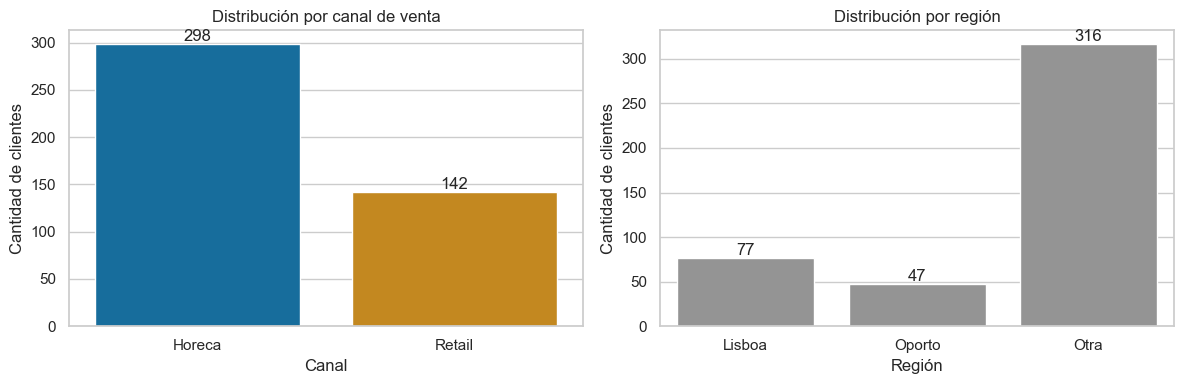

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

orden_canal = ["Horeca", "Retail"]
orden_region = ["Lisboa", "Oporto", "Otra"]

sns.countplot(data=df, x="Canal", order=orden_canal, hue="Canal",
              palette=COLOR_CANAL, legend=False, ax=ejes[0])
ejes[0].set_title("Distribución por canal de venta")

sns.countplot(data=df, x="Región", order=orden_region, color=PALETA[7], ax=ejes[1])
ejes[1].set_title("Distribución por región")

for eje in ejes:
    eje.set_ylabel("Cantidad de clientes")
    for contenedor in eje.containers:
        eje.bar_label(contenedor)

fig.tight_layout()
guardar_figura(fig, "eda_categoricas")
plt.show()

**Interpretación.** La muestra está desbalanceada en ambas variables: el canal Horeca concentra el 67,7 % de los clientes (298) frente al 32,3 % de Retail (142), y el 71,8 % de las observaciones (316) proviene de regiones distintas de Lisboa y Oporto. La tabla de contingencia muestra que la composición por canal es relativamente similar entre regiones (la proporción de Retail varía entre el 23 % en Lisboa y el 40 % en Oporto), por lo que no se aprecia una interacción fuerte entre ambas variables. Dado el desbalance y la escasa granularidad de `Region`, se anticipa que el canal será la pseudo-etiqueta más informativa para la validación externa.

### 3.3 Estadísticas descriptivas de las variables de gasto

Se calculan las estadísticas descriptivas de las seis variables de gasto: medidas de posición (media, mediana, cuartiles), de dispersión (desvío estándar, mínimo y máximo) y de forma. Estas últimas son especialmente relevantes para lo que sigue: la **asimetría** (*skewness*, igual a 0 en una distribución simétrica) y la **curtosis en exceso** (igual a 0 en una distribución normal) permiten cuantificar el alejamiento de la normalidad, condición que afecta tanto a los algoritmos basados en distancias euclídeas como a los modelos de mezclas gaussianas.

In [7]:
descriptivos = df[VARS_GASTO].describe().T
descriptivos["asimetría"] = df[VARS_GASTO].skew()
descriptivos["curtosis"] = df[VARS_GASTO].kurtosis()
descriptivos.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis
Fresh,440.0,12000.30,12647.33,3.0,3127.75,8504.0,16933.75,112151.0,2.56,11.54
Milk,440.0,5796.27,7380.38,55.0,1533.00,3627.0,7190.25,73498.0,4.05,24.67
Grocery,440.0,7951.28,9503.16,3.0,2153.00,4755.5,10655.75,92780.0,3.59,20.91
Frozen,440.0,3071.93,4854.67,25.0,742.25,1526.0,3554.25,60869.0,5.91,54.69
Detergents_Paper,440.0,2881.49,4767.85,3.0,256.75,816.5,3922.00,40827.0,3.63,19.01
Delicassen,440.0,1524.87,2820.11,3.0,408.25,965.5,1820.25,47943.0,11.15,170.69


**Interpretación.** Las seis variables presentan una **asimetría positiva severa**: en todas ellas la media supera ampliamente a la mediana (por ejemplo, `Fresh`: media 12 000 u.m. frente a mediana 8 504 u.m.) y en cuatro de las seis el desvío estándar supera a la media, lo que indica una dispersión extrema. Los coeficientes de asimetría oscilan entre 2,56 (`Fresh`) y 11,15 (`Delicassen`), y la curtosis alcanza valores de hasta 170,7 (`Delicassen`), evidencia de colas derechas muy pesadas: una minoría de clientes de gran volumen convive con una mayoría de clientes de gasto moderado.

Este comportamiento es típico de variables monetarias y tiene dos consecuencias metodológicas directas: (i) las distancias euclídeas quedarían dominadas por los clientes de mayor gasto si no se transforma la escala, y (ii) el supuesto gaussiano de los modelos de mezclas resultaría poco plausible sobre los datos crudos. Ambas observaciones motivan la transformación logarítmica que se evalúa a continuación.

### 3.4 Distribuciones: escala original y escala logarítmica

Se representan los histogramas con estimación de densidad (KDE) de las seis variables de gasto, primero en su escala original y luego tras aplicar la transformación `log1p` (logaritmo natural de 1 + x). Se utiliza `log1p` en lugar del logaritmo directo por robustez: aunque en este dataset todos los valores son estrictamente positivos, `log1p` está definida en cero y su efecto sobre valores grandes es indistinguible del logaritmo simple. La comparación visual de ambas escalas permite evaluar si la transformación corrige la asimetría detectada en la sección anterior.

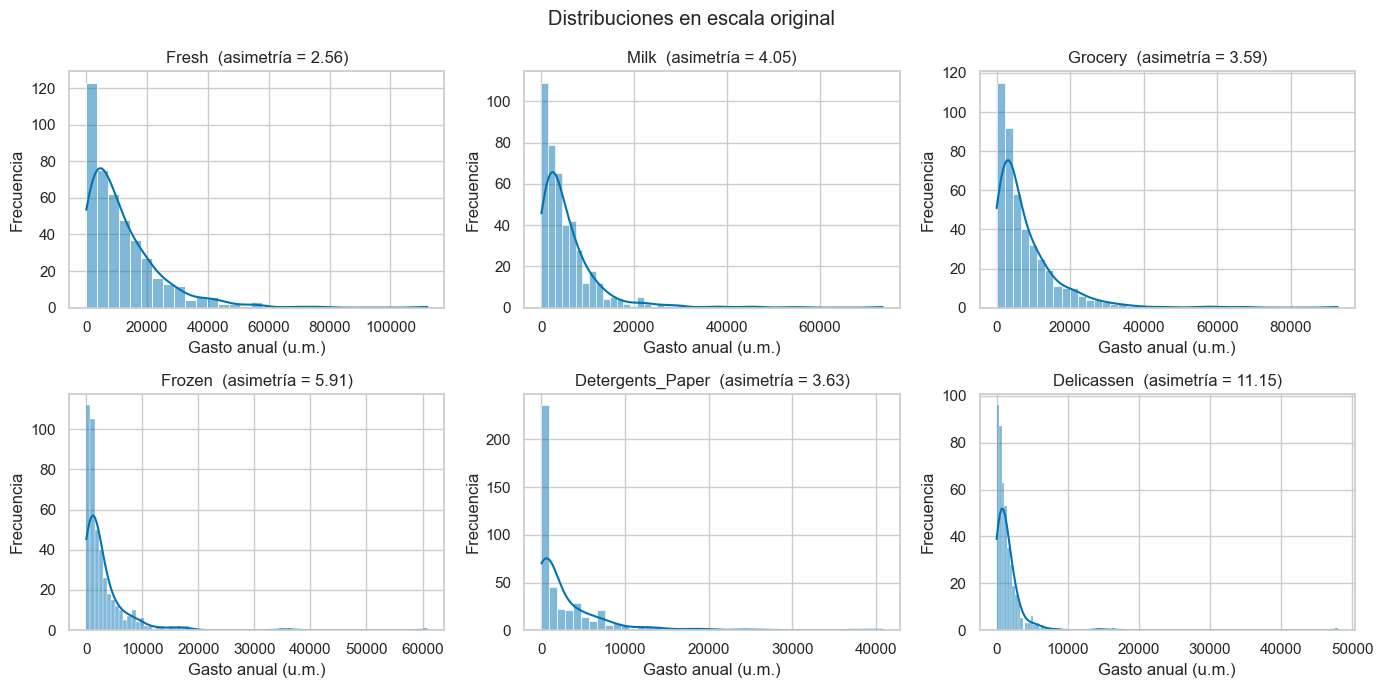

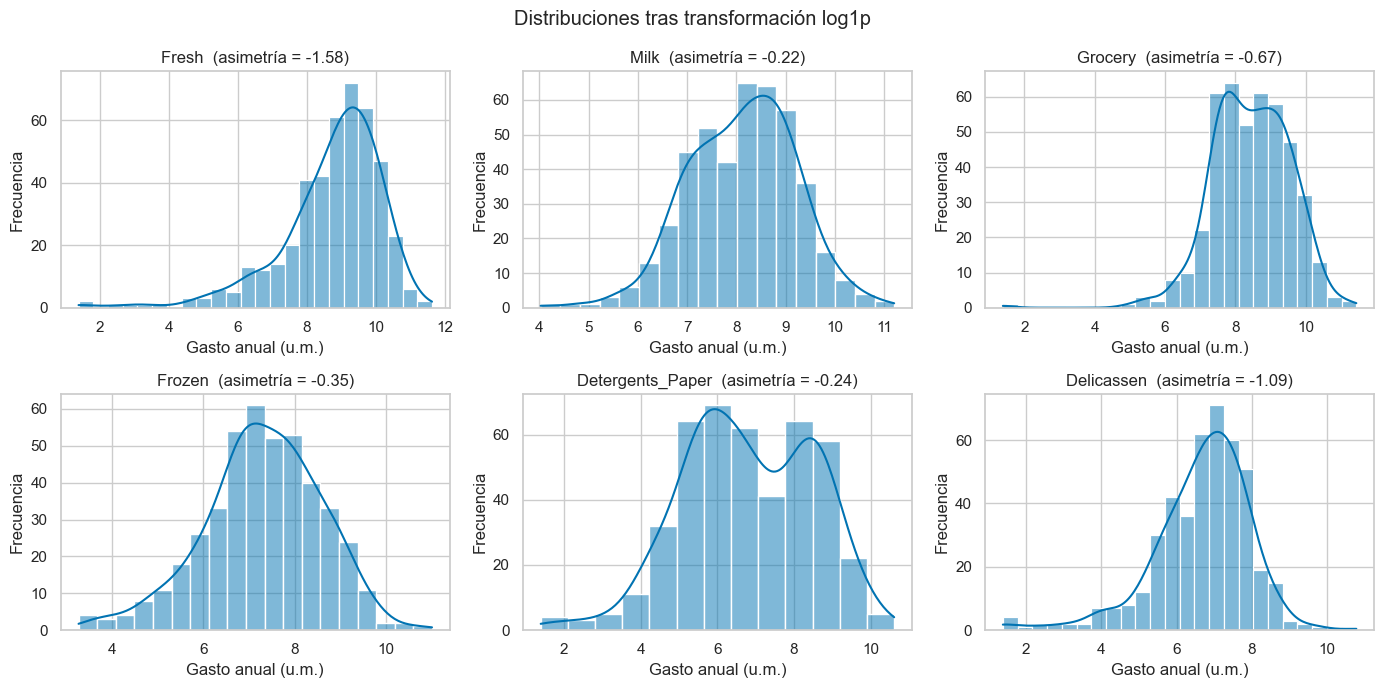

In [8]:
def graficar_distribuciones(datos, titulo, nombre_archivo):
    fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
    for eje, col in zip(ejes.ravel(), VARS_GASTO):
        sns.histplot(datos[col], kde=True, color=PALETA[0], ax=eje)
        eje.set_title(f"{col}  (asimetría = {datos[col].skew():.2f})")
        eje.set_xlabel("Gasto anual (u.m.)")
        eje.set_ylabel("Frecuencia")
    fig.suptitle(titulo)
    fig.tight_layout()
    guardar_figura(fig, nombre_archivo)
    plt.show()


graficar_distribuciones(df[VARS_GASTO], "Distribuciones en escala original",
                        "eda_distribuciones_original")
graficar_distribuciones(np.log1p(df[VARS_GASTO]),
                        "Distribuciones tras transformación log1p",
                        "eda_distribuciones_log")

**Interpretación.** En escala original las seis distribuciones concentran la masa cerca del origen con colas derechas muy largas, coherente con los coeficientes de asimetría calculados. Tras la transformación logarítmica, las distribuciones se vuelven aproximadamente unimodales y mucho más simétricas: la asimetría residual se reduce a valores entre −1,58 (`Fresh`) y −0,22 (`Milk`). La leve asimetría negativa remanente en `Fresh` y `Delicassen` se explica por los clientes con gasto casi nulo detectados en 3.1, cuyo logaritmo produce valores aislados en el extremo inferior.

La evidencia respalda adoptar la transformación logarítmica en el preprocesamiento: acerca los datos a las condiciones de aplicabilidad de los algoritmos basados en distancias y del modelo de mezclas gaussianas.

### 3.5 Correlaciones entre variables de gasto

Se calculan dos matrices de correlación complementarias: **Pearson**, que mide asociación lineal pero es sensible a valores extremos, y **Spearman**, basada en rangos y por tanto robusta frente a los outliers y a la asimetría documentadas en las secciones previas. La coincidencia de ambas matrices indicaría que las asociaciones observadas reflejan la estructura general de los datos y no el efecto de unos pocos clientes extremos. Se emplea una escala de color divergente centrada en cero, de modo que el tono codifica el signo de la correlación y la intensidad su magnitud.

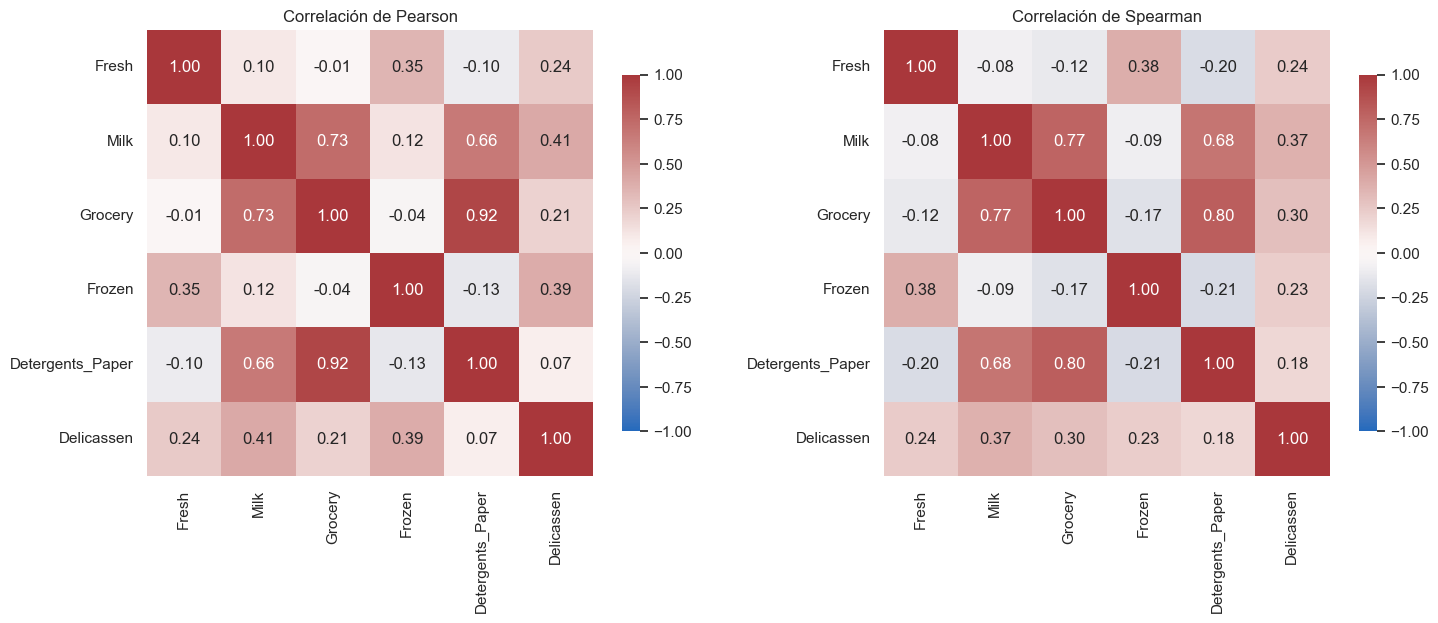

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

for eje, metodo in zip(ejes, ["pearson", "spearman"]):
    matriz = df[VARS_GASTO].corr(method=metodo)
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="vlag", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=eje)
    eje.set_title(f"Correlación de {metodo.capitalize()}")

fig.tight_layout()
guardar_figura(fig, "eda_correlaciones")
plt.show()

**Interpretación.** Ambas matrices coinciden en lo esencial, lo que descarta que las asociaciones sean un artefacto de los valores extremos. Se identifica un **bloque fuertemente correlacionado** formado por `Grocery`, `Milk` y `Detergents_Paper` (Pearson: 0,93 entre `Grocery` y `Detergents_Paper`; 0,73 entre `Milk` y `Grocery`; Spearman confirma con 0,80 y 0,77 respectivamente), interpretable como una *canasta de reposición minorista*. Un segundo eje, más débil, asocia `Fresh` con `Frozen` (0,35), compatible con el perfil de compra de la hostelería. `Delicassen` muestra correlaciones moderadas y difusas con el resto.

Dos implicaciones para el modelado: (i) la redundancia del bloque `Grocery`–`Milk`–`Detergents_Paper` sugiere que la dimensionalidad efectiva de los datos es menor que las seis variables observadas, lo que da sustento al uso de representaciones latentes (autoencoder en DEC) y de técnicas de reducción de dimensionalidad para visualización; (ii) la existencia de ejes de compra diferenciados anticipa una estructura de grupos separable.

### 3.6 Detección de valores atípicos

Se aplica el criterio estándar del **rango intercuartílico (IQR)**: se considera atípico todo valor situado por debajo de Q1 − 1,5·IQR o por encima de Q3 + 1,5·IQR. Los diagramas de caja permiten visualizar la magnitud del fenómeno en cada variable, y la tabla resume la cantidad y proporción de observaciones atípicas por variable, además del total de filas afectadas por al menos un valor atípico — cifra determinante para decidir el tratamiento.

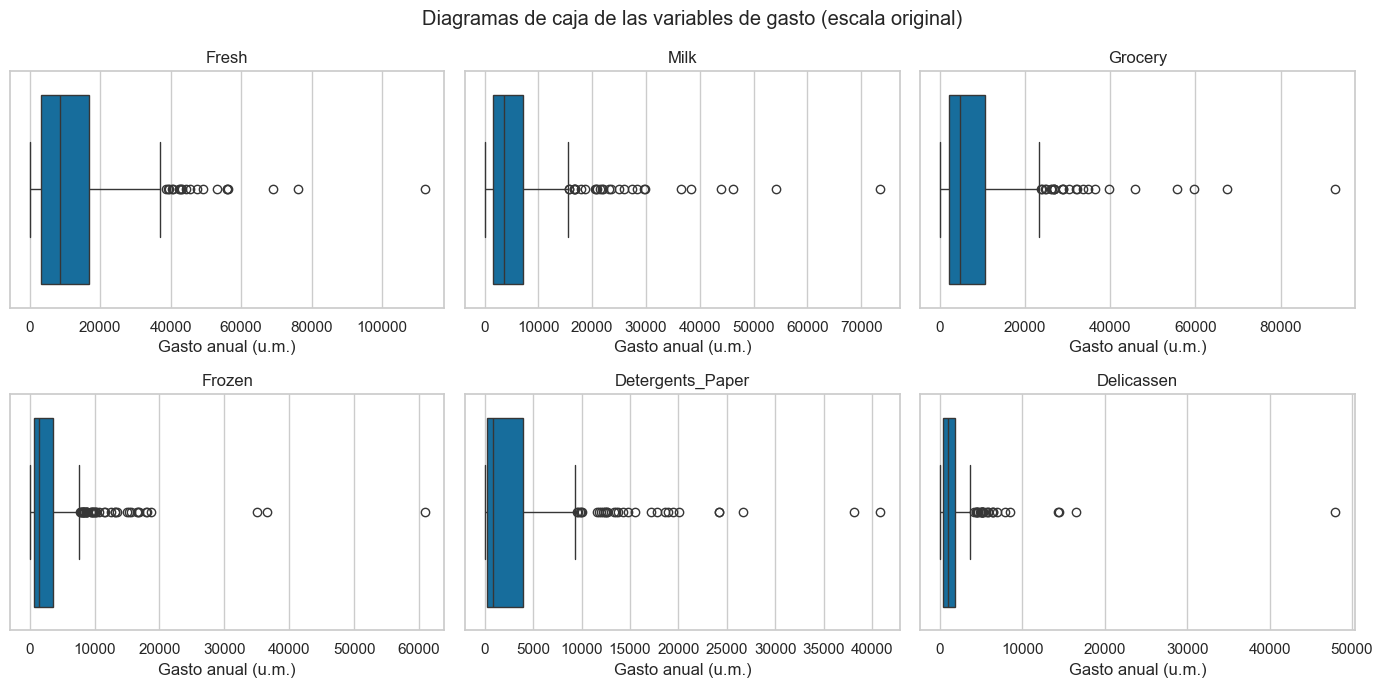

Filas con al menos un valor atípico: 108 de 440 (24.5 %)


,outliers,proporción
Fresh,20.0,0.045
Milk,28.0,0.064
Grocery,24.0,0.055
Frozen,43.0,0.098
Detergents_Paper,30.0,0.068
Delicassen,27.0,0.061


In [10]:
fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
for eje, col in zip(ejes.ravel(), VARS_GASTO):
    sns.boxplot(x=df[col], color=PALETA[0], ax=eje)
    eje.set_title(col)
    eje.set_xlabel("Gasto anual (u.m.)")
fig.suptitle("Diagramas de caja de las variables de gasto (escala original)")
fig.tight_layout()
guardar_figura(fig, "eda_boxplots")
plt.show()


def resumen_outliers_iqr(datos):
    filas = {}
    fuera_alguna = pd.Series(False, index=datos.index)
    for col in datos.columns:
        q1, q3 = datos[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        fuera = (datos[col] < q1 - 1.5 * iqr) | (datos[col] > q3 + 1.5 * iqr)
        fuera_alguna |= fuera
        filas[col] = {"outliers": int(fuera.sum()),
                      "proporción": round(float(fuera.mean()), 3)}
    resumen = pd.DataFrame(filas).T
    total = int(fuera_alguna.sum())
    print(f"Filas con al menos un valor atípico: {total} de {len(datos)} "
          f"({100 * total / len(datos):.1f} %)")
    return resumen


resumen_outliers_iqr(df[VARS_GASTO])

**Interpretación y decisión de tratamiento.** Cada variable presenta entre un 4,5 % (`Fresh`) y un 9,8 % (`Frozen`) de valores atípicos, pero el dato decisivo es agregado: **108 filas (el 24,5 % de la muestra) contienen al menos un valor atípico**. Eliminar estas observaciones supondría descartar una cuarta parte de un dataset ya reducido (440 observaciones) y, más importante, los valores extremos no son errores de medición sino **clientes de gran volumen reales** — precisamente un segmento de alto interés comercial que el agrupamiento debería poder caracterizar, no ignorar.

En consecuencia, se decide **conservar todas las observaciones** y mitigar la influencia de los valores extremos mediante la transformación logarítmica justificada en 3.4, que comprime las colas de forma monótona sin descartar información. La sensibilidad de cada algoritmo a los valores extremos remanentes se discutirá al comparar los resultados.

### 3.7 Perfil de gasto según canal de venta

Dado que `Channel` se reserva como pseudo-etiqueta para la validación externa, interesa verificar de antemano si los perfiles de gasto difieren entre canales: de ser así, cabría esperar que los algoritmos de agrupamiento recuperen, al menos parcialmente, esa partición. Se comparan las distribuciones de las seis categorías de gasto entre Horeca y Retail mediante diagramas de caja sobre **escala logarítmica**, que permite comparar variables de magnitudes muy distintas en un mismo eje y atenúa visualmente los extremos ya discutidos.

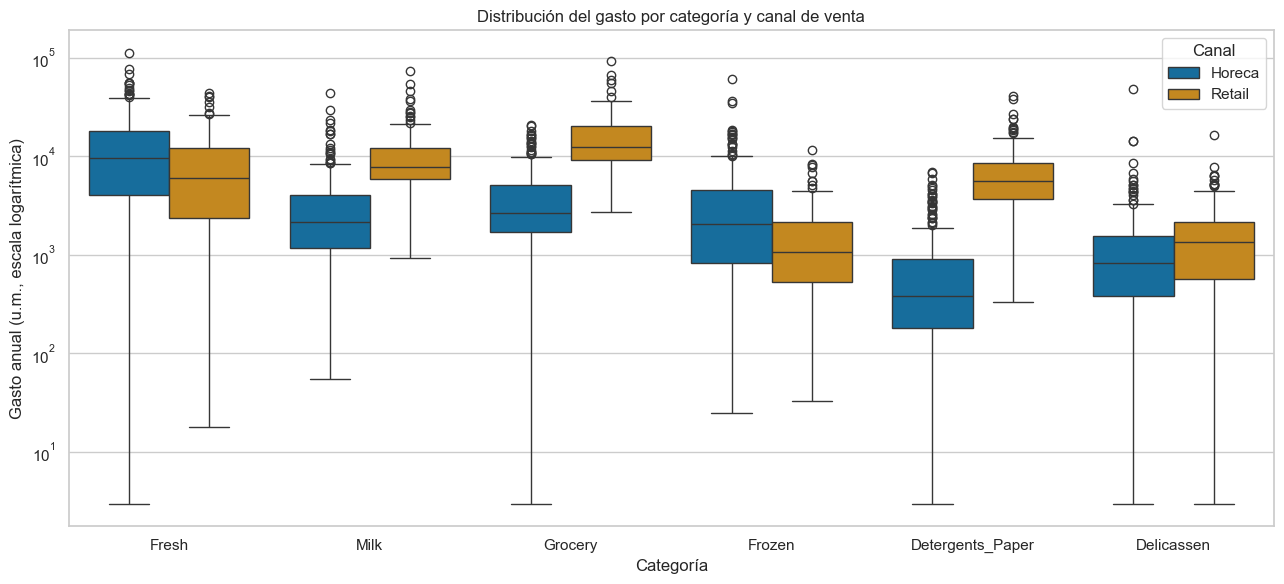

Mediana de gasto anual (u.m.) por canal:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Canal,,,,,,
Horeca,9582.0,2157.0,2684.0,2058.0,386.0,821.0
Retail,5994.0,7812.0,12390.0,1081.0,5614.0,1350.0


In [11]:
gasto_largo = df.melt(id_vars="Canal", value_vars=VARS_GASTO,
                      var_name="Categoría", value_name="Gasto")

fig, eje = plt.subplots(figsize=(13, 6))
sns.boxplot(data=gasto_largo, x="Categoría", y="Gasto", hue="Canal",
            hue_order=["Horeca", "Retail"], palette=COLOR_CANAL, ax=eje)
eje.set_yscale("log")
eje.set_ylabel("Gasto anual (u.m., escala logarítmica)")
eje.set_title("Distribución del gasto por categoría y canal de venta")
fig.tight_layout()
guardar_figura(fig, "eda_gasto_por_canal")
plt.show()

print("Mediana de gasto anual (u.m.) por canal:")
df.groupby("Canal")[VARS_GASTO].median().round(0)

**Interpretación.** Los perfiles de gasto de ambos canales difieren de forma marcada y coherente con el dominio. Los clientes **Retail** gastan sustancialmente más en la canasta de reposición minorista: su mediana en `Grocery` (12 390 u.m.) multiplica por 4,6 la de Horeca (2 684 u.m.), en `Detergents_Paper` (5 615 u.m.) la multiplica por 14,6 (386 u.m.) y en `Milk` por 3,6. Los clientes **Horeca**, en cambio, presentan medianas superiores en `Fresh` (9 582 frente a 5 994 u.m.) y `Frozen` (2 058 frente a 1 081 u.m.), consistente con el consumo de insumos perecederos de la hostelería.

Esta separación, alineada con el bloque de correlaciones identificado en 3.5, permite formular la hipótesis de que la estructura de grupos dominante en los datos estará asociada al canal de venta, con `Detergents_Paper` y `Grocery` como ejes discriminantes principales.

### 3.8 Conclusiones del análisis exploratorio

Las conclusiones del EDA, que condicionan las decisiones metodológicas de las secciones siguientes, se resumen a continuación:

1. **Calidad:** el dataset está completo (sin nulos ni duplicados) y no requiere imputación; las 440 observaciones son utilizables.
2. **Escala y forma:** las seis variables de gasto presentan asimetría positiva severa (coeficientes entre 2,6 y 11,2) y colas pesadas; la transformación logarítmica corrige sustancialmente este comportamiento y se adopta en el preprocesamiento, seguida de un escalado que homogeneice varianzas antes de aplicar algoritmos basados en distancias.
3. **Estructura de correlación:** existe un bloque fuertemente correlacionado (`Grocery`–`Milk`–`Detergents_Paper`) y un eje secundario (`Fresh`–`Frozen`), lo que sugiere una dimensionalidad efectiva menor que 6 y anticipa estructura de grupos separable.
4. **Valores atípicos:** el 24,5 % de las filas contiene al menos un valor atípico según el criterio IQR; se conservan todas las observaciones por tratarse de clientes reales de gran volumen, mitigando su influencia mediante la transformación logarítmica.
5. **Hipótesis de trabajo:** los perfiles de gasto difieren claramente entre canales (Horeca orientado a frescos y congelados; Retail a almacén, lácteos y detergentes), por lo que se espera que la estructura de grupos recuperada guarde relación con `Channel`, variable que se empleará como pseudo-etiqueta en la evaluación externa. Un rango inicial razonable para el número de grupos es k ∈ {2, …, 6}, a validar con criterios internos en cada algoritmo.
6. **Variables de agrupamiento:** el clustering se realizará exclusivamente sobre las seis variables de gasto; `Channel` y `Region` quedan excluidas del espacio de atributos y reservadas para validación externa e interpretación.

## 4. Preprocesamiento

Las decisiones de preprocesamiento se derivan directamente de las conclusiones del EDA (sección 3.8). En síntesis: (i) **no se requiere imputación**, dado que el dataset no presenta valores nulos (3.1); (ii) **no se requiere codificación de variables categóricas**, dado que `Channel` y `Region` quedan excluidas del espacio de atributos; (iii) se aplica una **transformación logarítmica** para corregir la asimetría severa (3.4) y mitigar la influencia de los valores atípicos conservados (3.6); y (iv) se aplica un **escalado** que homogeneice las varianzas antes de utilizar algoritmos basados en distancias. El pipeline resultante es: selección de variables → `log1p` → estandarización.

### 4.1 Selección de variables

El agrupamiento se realiza exclusivamente sobre las seis variables de gasto. La exclusión de `Channel` y `Region` responde a dos razones metodológicas: primero, el objetivo del trabajo es descubrir la estructura de grupos **sin supervisión**, a partir del comportamiento de compra observado; segundo, `Channel` se emplea en la sección 9 como pseudo-etiqueta para la evaluación externa, e incluirla como atributo introduciría circularidad en dicha validación (los clusters reproducirían trivialmente la variable con la que luego se los evalúa).

En la celda siguiente se construye la matriz de atributos cruda (`X_crudo`, de dimensión 440 × 6) y se reservan las etiquetas de canal y región en vectores separados, que se utilizarán únicamente para evaluación e interpretación.

In [12]:
X_crudo = df[VARS_GASTO].copy()
y_canal = df["Canal"].to_numpy()
y_region = df["Región"].to_numpy()

print(f"Matriz de atributos: {X_crudo.shape[0]} observaciones × {X_crudo.shape[1]} variables")
X_crudo.head()

Matriz de atributos: 440 observaciones × 6 variables


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


### 4.2 Transformación logarítmica

Se aplica `log1p` (logaritmo natural de 1 + x) a las seis variables de gasto, conforme a la justificación desarrollada en 3.4: la transformación es monótona (preserva el orden relativo de los clientes), comprime las colas derechas pesadas y acerca las distribuciones a la simetría, condición favorable tanto para las distancias euclídeas como para el supuesto gaussiano de los modelos de mezclas.

La celda siguiente aplica la transformación y verifica su efecto comparando los coeficientes de asimetría antes y después, junto con la cantidad de valores atípicos (criterio IQR) remanentes por variable.

In [13]:
X_log = np.log1p(X_crudo)

verificacion = pd.DataFrame({
    "asimetría original": X_crudo.skew(),
    "asimetría tras log1p": X_log.skew(),
})
for col in VARS_GASTO:
    q1, q3 = X_log[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = (X_log[col] < q1 - 1.5 * iqr) | (X_log[col] > q3 + 1.5 * iqr)
    verificacion.loc[col, "outliers IQR tras log1p"] = int(fuera.sum())

verificacion.round(2)

,asimetría original,asimetría tras log1p,outliers IQR tras log1p
Fresh,2.56,-1.58,16.0
Milk,4.05,-0.22,4.0
Grocery,3.59,-0.67,2.0
Frozen,5.91,-0.35,10.0
Detergents_Paper,3.63,-0.24,2.0
Delicassen,11.15,-1.09,14.0


**Verificación.** La asimetría se reduce de valores entre 2,56 y 11,15 a valores residuales entre −1,58 y −0,22, y las filas afectadas por valores atípicos caen del 24,5 % al 9,5 %. Los atípicos remanentes se concentran en la **cola inferior** (los clientes con gasto casi nulo identificados en 3.1, cuyo logaritmo produce valores aislados en el extremo inferior), un fenómeno mucho menos distorsivo para el agrupamiento que las colas superiores originales, donde un único cliente podía distar órdenes de magnitud del resto.

### 4.3 Estandarización

Aun tras la transformación logarítmica, las variables presentan medias distintas (entre 6,67 y 8,73 en escala log) y varianzas heterogéneas. Sin un escalado posterior, las variables de mayor varianza dominarían las distancias euclídeas empleadas por Agglomerative Clustering (en particular con enlace de Ward), condicionarían las covarianzas estimadas por el modelo de mezclas y dificultarían el entrenamiento por gradiente del autoencoder de DEC. Se comparan tres alternativas habituales:

- **`StandardScaler`** (media 0, desvío 1): apropiado cuando las distribuciones son aproximadamente simétricas, condición que la transformación logarítmica ya garantiza.
- **`RobustScaler`** (mediana y rango intercuartílico): preferible cuando persisten valores atípicos severos que distorsionarían la media y el desvío; tras `log1p` los atípicos remanentes son pocos (9,5 % de las filas) y moderados, por lo que su ventaja se diluye.
- **`MinMaxScaler`** (rango [0, 1]): sensible a los valores extremos, que definen los límites del rango; se descarta por los atípicos remanentes en la cola inferior.

Se adopta en consecuencia **`StandardScaler` sobre los datos transformados**, la combinación estándar en la literatura para variables monetarias. La celda siguiente ajusta el escalador y verifica el resultado (media ≈ 0 y desvío ≈ 1 en todas las variables).

In [14]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_esc = pd.DataFrame(escalador.fit_transform(X_log),
                     columns=VARS_GASTO, index=X_log.index)

X_esc.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Fresh,0.0,1.0,-5.00,1.97
Milk,-0.0,1.0,-3.79,2.86
Grocery,-0.0,1.0,-6.36,2.70
Frozen,0.0,1.0,-3.16,2.90
Detergents_Paper,-0.0,1.0,-3.17,2.24
Delicassen,-0.0,1.0,-4.09,3.18


La figura siguiente muestra los diagramas de caja de la matriz final: las seis variables quedan en escalas comparables, con la mayor parte de la masa en el intervalo [−2, 2]. Los valores mínimos alejados (hasta −6,4 desvíos en `Grocery`) corresponden a los clientes de actividad casi nula ya documentados; se conservan por las razones expuestas en 3.6.

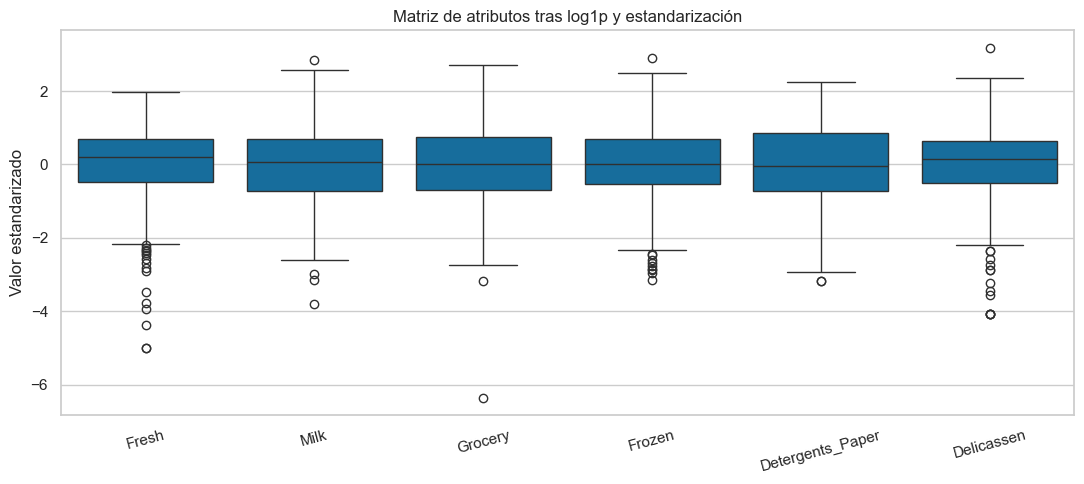

In [15]:
fig, eje = plt.subplots(figsize=(11, 5))
sns.boxplot(data=X_esc, color=PALETA[0], ax=eje)
eje.set_title("Matriz de atributos tras log1p y estandarización")
eje.set_ylabel("Valor estandarizado")
eje.tick_params(axis="x", rotation=15)
fig.tight_layout()
guardar_figura(fig, "prep_matriz_final")
plt.show()

### 4.4 Síntesis del preprocesamiento

El resultado del preprocesamiento es la matriz `X_esc` (440 × 6), obtenida mediante `log1p` seguida de estandarización, sin eliminación de observaciones. **Todos los algoritmos de las secciones 5 a 8 se entrenan sobre esta misma matriz**, lo que garantiza que las diferencias de desempeño observadas en la sección 9 sean atribuibles a los métodos y no a diferencias en la preparación de los datos. Las variables `Channel` y `Region` permanecen fuera del espacio de atributos, reservadas para la evaluación externa y la interpretación de los grupos.

## 5. Baseline de referencia: K-Means

K-Means particiona las observaciones en *k* grupos minimizando la suma de distancias cuadráticas intra-cluster (inercia). Conforme a la consigna, **se emplea únicamente como referencia**: es el método más difundido y su resultado establece un piso de comparación, pero no computa como uno de los dos algoritmos requeridos. Sus limitaciones — supone clusters esféricos de tamaño similar, depende de la inicialización y fuerza asignaciones duras — son precisamente las que los métodos de las secciones 6 a 8 relajan.

Para seleccionar el número de grupos, la celda siguiente recorre k ∈ {2, …, 8} con 20 inicializaciones aleatorias por valor (`n_init=20`, que reduce el riesgo de óptimos locales) y combina dos criterios: el **método del codo** sobre la inercia (buscar el punto donde la ganancia marginal de agregar grupos se atenúa) y el **coeficiente de silhouette** promedio (cohesión frente a separación; mayor es mejor).

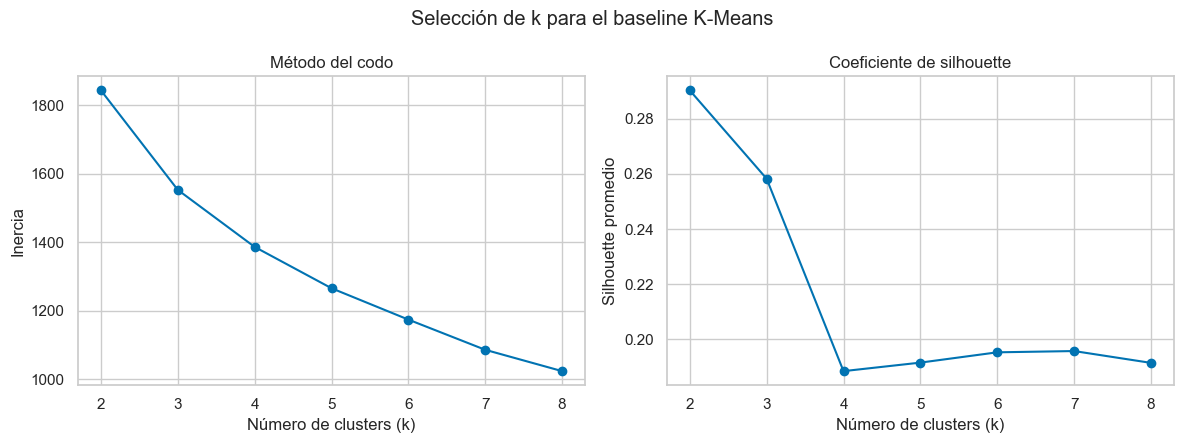

,k,inercia,silhouette
0,2,1844.064,0.290
1,3,1553.413,0.258
2,4,1386.863,0.188
3,5,1266.149,0.192
4,6,1174.536,0.195
5,7,1086.359,0.196
6,8,1024.047,0.191


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

rango_k = list(range(2, 9))
inercias, siluetas = [], []
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_esc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_esc, km.labels_))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
ejes[0].plot(rango_k, inercias, marker="o", color=PALETA[0])
ejes[0].set_title("Método del codo")
ejes[0].set_xlabel("Número de clusters (k)")
ejes[0].set_ylabel("Inercia")
ejes[1].plot(rango_k, siluetas, marker="o", color=PALETA[0])
ejes[1].set_title("Coeficiente de silhouette")
ejes[1].set_xlabel("Número de clusters (k)")
ejes[1].set_ylabel("Silhouette promedio")
fig.suptitle("Selección de k para el baseline K-Means")
fig.tight_layout()
guardar_figura(fig, "kmeans_seleccion_k")
plt.show()

pd.DataFrame({"k": rango_k, "inercia": inercias, "silhouette": siluetas}).round(3)

**Interpretación.** La inercia decrece de forma suave, sin un codo marcado — indicio de que los datos no presentan grupos fuertemente separados a ningún k. El coeficiente de silhouette es máximo en **k = 2** (0,290) y decae a partir de allí, con valores moderados en todo el rango, esperables en datos reales con fronteras difusas. Se adopta k = 2 para el baseline y se ajusta el modelo definitivo; sus etiquetas se almacenan en el diccionario `etiquetas_finales`, que irá acumulando la partición definitiva de cada método para la comparación global de la sección 9.

In [17]:
kmeans_final = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(X_esc)

# Diccionario que acumula las etiquetas definitivas de cada método (sección 9)
etiquetas_finales = {"K-Means (k=2, referencia)": kmeans_final.labels_}

print("Tamaños de los clusters:", np.bincount(kmeans_final.labels_))

Tamaños de los clusters: [252 188]


## 6. Agglomerative Clustering

El agrupamiento jerárquico aglomerativo construye la partición de abajo hacia arriba: parte de 440 clusters unitarios y fusiona en cada paso el par más próximo según el criterio de **enlace** (*linkage*). A diferencia de K-Means, es determinista (no depende de inicializaciones), no impone forma esférica y produce una jerarquía completa — el **dendrograma** — que permite inspeccionar la estructura a todas las escalas antes de fijar el número de grupos.

Se evalúan los cuatro criterios de enlace clásicos: **Ward** (minimiza el incremento de varianza intra-cluster; tiende a grupos compactos y balanceados), **complete** (distancia máxima entre pares), **average** (distancia promedio) y **single** (distancia mínima; propenso al encadenamiento). La celda siguiente construye primero el dendrograma con enlace de Ward — truncado a 30 hojas para su legibilidad, con el recuento de observaciones de cada hoja entre paréntesis — y marca la altura de corte que produce tres clusters.

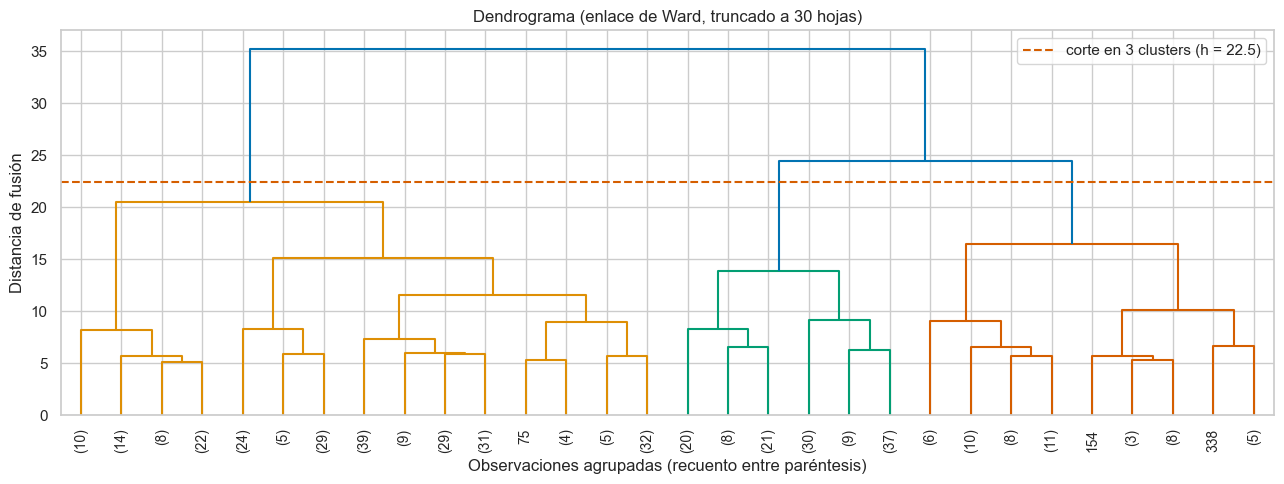

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_esc, method="ward")

# Altura de corte que produce k=3 clusters: entre las dos últimas fusiones
altura_corte = (Z[-3, 2] + Z[-2, 2]) / 2

fig, eje = plt.subplots(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True,
           leaf_rotation=90, color_threshold=altura_corte, ax=eje)
eje.axhline(altura_corte, color=PALETA[3], linestyle="--",
            label=f"corte en 3 clusters (h = {altura_corte:.1f})")
eje.set_title("Dendrograma (enlace de Ward, truncado a 30 hojas)")
eje.set_xlabel("Observaciones agrupadas (recuento entre paréntesis)")
eje.set_ylabel("Distancia de fusión")
eje.legend()
fig.tight_layout()
guardar_figura(fig, "agglo_dendrograma")
plt.show()

**Interpretación.** El dendrograma muestra dos ramas principales de tamaño comparable — coherente con la hipótesis de estructura asociada al canal formulada en 3.8 — y, dentro de una de ellas, una subdivisión secundaria claramente definida: cortar por debajo de esa fusión produce tres grupos. Las alturas de fusión sugieren que las particiones de 2 o 3 clusters son las más naturales.

La celda siguiente optimiza los hiperparámetros mediante una grilla exhaustiva `linkage` × `k` (4 × 5 = 20 configuraciones), evaluada con las tres métricas internas y con el **tamaño del cluster más pequeño** de cada partición — dato imprescindible para detectar soluciones degeneradas, como se verá. La tabla se presenta ordenada por silhouette descendente.

In [19]:
from sklearn.cluster import AgglomerativeClustering

resultados_agg = []
for metodo in ["ward", "complete", "average", "single"]:
    for k in range(2, 7):
        etiq = AgglomerativeClustering(n_clusters=k, linkage=metodo).fit(X_esc).labels_
        tam = np.bincount(etiq)
        resultados_agg.append({
            "linkage": metodo,
            "k": k,
            "silhouette": silhouette_score(X_esc, etiq),
            "davies_bouldin": davies_bouldin_score(X_esc, etiq),
            "calinski_harabasz": calinski_harabasz_score(X_esc, etiq),
            "cluster_mínimo": int(tam.min()),
            "tamaños": tam.tolist(),
        })

tabla_agg = pd.DataFrame(resultados_agg).round(3)
tabla_agg.sort_values("silhouette", ascending=False)

,linkage,k,silhouette,davies_bouldin,calinski_harabasz,cluster_mínimo,tamaños
15,single,2,0.570,0.307,8.964,1,"[439, 1]"
10,average,2,0.569,0.883,13.965,2,"[2, 438]"
11,average,3,0.542,0.307,9.055,1,"[438, 1, 1]"
16,single,3,0.506,0.340,7.870,1,"[438, 1, 1]"
12,average,4,0.498,0.330,8.383,1,"[437, 1, 1, 1]"
17,single,4,0.498,0.330,8.383,1,"[437, 1, 1, 1]"
18,single,5,0.397,0.371,7.399,1,"[436, 1, 1, 1, 1]"
13,average,5,0.383,0.547,11.898,1,"[431, 6, 1, 1, 1]"
19,single,6,0.357,0.379,6.924,1,"[435, 1, 1, 1, 1, 1]"
14,average,6,0.331,0.732,13.917,1,"[423, 6, 8, 1, 1, 1]"


**Interpretación crítica y elección.** La tabla ilustra un riesgo metodológico central del agrupamiento: **optimizar una métrica interna a ciegas conduce a soluciones degeneradas**. Los enlaces single y average alcanzan las mejores silhouettes (hasta 0,570) aislando 1 o 2 clientes extremos en un cluster propio y agrupando los ~438 restantes en otro; complete presenta el mismo defecto atenuado (particiones como [38, 402]). Estas soluciones son inútiles como segmentación: no describen la estructura de la cartera de clientes, sino los valores atípicos conservados en 3.6.

Se descartan en consecuencia las particiones cuyo cluster mínimo no alcanza el 5 % de la muestra (22 observaciones). Entre las restantes — todas con enlace de **Ward** — compiten k = 2 (silhouette 0,258) y k = 3 (silhouette 0,255, con mejor Davies-Bouldin: 1,539 frente a 1,600). Se adopta **Ward con k = 3**: la diferencia de silhouette es marginal, el dendrograma respalda la subdivisión secundaria y la partición resultante (tamaños [262, 53, 125]) ofrece una segmentación más rica que la dicotomía del baseline. La elección se fundamenta exclusivamente en criterios internos y estructurales; la contrastación con la pseudo-etiqueta se reserva para la sección 9.

In [20]:
agg_final = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_esc)
etiquetas_finales["Agglomerative (Ward, k=3)"] = agg_final.labels_

print("Tamaños de los clusters:", np.bincount(agg_final.labels_))

Tamaños de los clusters: [262  53 125]


## 7. Gaussian Mixture Models

El modelo de mezclas gaussianas (GMM) es un método **probabilístico y generativo**: supone que los datos provienen de una mezcla de k distribuciones normales multivariadas y estima sus parámetros por máxima verosimilitud mediante el algoritmo EM. Frente a los métodos anteriores aporta dos ventajas: admite clusters elipsoidales de orientación y volumen arbitrarios (según la parametrización de las covarianzas) y produce **asignaciones blandas** — cada cliente recibe una probabilidad de pertenencia a cada grupo. La transformación logarítmica del preprocesamiento vuelve plausible el supuesto de normalidad por componente (3.4).

La selección del modelo es aquí plenamente estadística: la celda siguiente recorre k ∈ {2, …, 8} combinado con las cuatro parametrizaciones de covarianza (`full`: cada componente con su matriz completa; `tied`: matriz completa compartida entre componentes; `diag`: matrices diagonales; `spherical`: varianza única por componente) y elige la configuración que minimiza el **criterio de información bayesiano (BIC)**, que penaliza la cantidad de parámetros y protege así contra el sobreajuste. Cada configuración se ajusta con 10 reinicios del algoritmo EM (`n_init=10`).

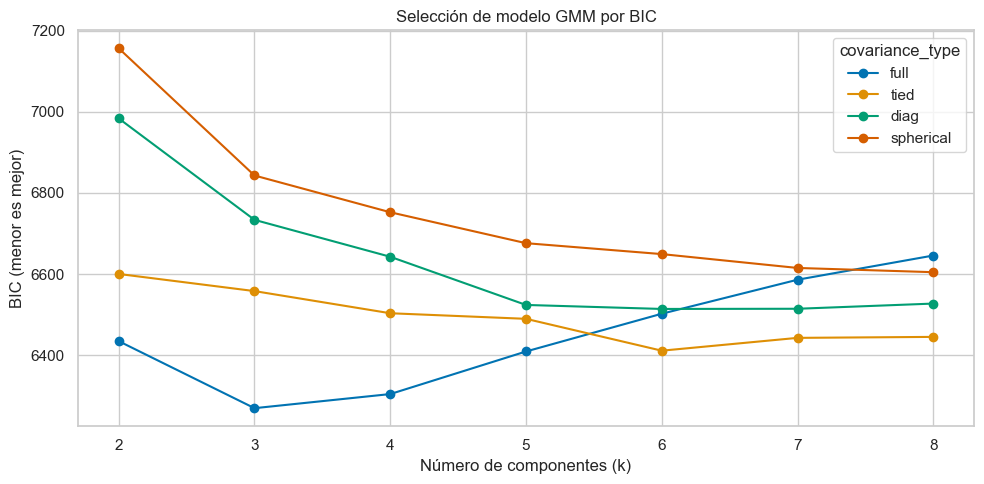

Mejor modelo por BIC: covariance_type=full, k=3, BIC=6269


In [21]:
from sklearn.mixture import GaussianMixture

tipos_cov = ["full", "tied", "diag", "spherical"]
resultados_gmm = []
for cov in tipos_cov:
    for k in range(2, 9):
        gmm = GaussianMixture(n_components=k, covariance_type=cov,
                              n_init=10, random_state=RANDOM_STATE).fit(X_esc)
        resultados_gmm.append({"covariance_type": cov, "k": k,
                               "BIC": gmm.bic(X_esc), "AIC": gmm.aic(X_esc)})
tabla_gmm = pd.DataFrame(resultados_gmm)

fig, eje = plt.subplots(figsize=(10, 5))
for i, cov in enumerate(tipos_cov):
    sub = tabla_gmm[tabla_gmm["covariance_type"] == cov]
    eje.plot(sub["k"], sub["BIC"], marker="o", color=PALETA[i], label=cov)
eje.set_xlabel("Número de componentes (k)")
eje.set_ylabel("BIC (menor es mejor)")
eje.set_title("Selección de modelo GMM por BIC")
eje.legend(title="covariance_type")
fig.tight_layout()
guardar_figura(fig, "gmm_seleccion_modelo")
plt.show()

mejor_gmm = tabla_gmm.loc[tabla_gmm["BIC"].idxmin()]
print(f"Mejor modelo por BIC: covariance_type={mejor_gmm['covariance_type']}, "
      f"k={int(mejor_gmm['k'])}, BIC={mejor_gmm['BIC']:.0f}")

**Interpretación.** El BIC selecciona **covarianza `full` con k = 3** (BIC = 6 269), seguida por `full` con k = 2. Que la parametrización completa domine a las restringidas es coherente con el bloque de correlaciones identificado en 3.5: las componentes necesitan covarianzas no diagonales para representar la asociación `Grocery`–`Milk`–`Detergents_Paper`. El mínimo en k = 3 indica además que, desde el punto de vista de la verosimilitud penalizada, existe estructura más fina que la dicotomía Horeca/Retail anticipada en el EDA.

La celda siguiente ajusta el modelo seleccionado y examina la ventaja distintiva del enfoque probabilístico: la **certeza de las asignaciones**, medida por la probabilidad máxima de pertenencia de cada cliente.

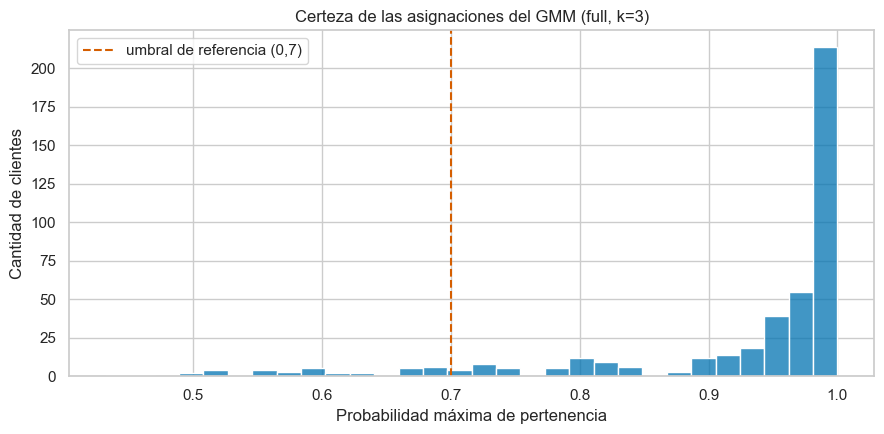

Tamaños de los clusters: [ 66 224 150]
Mediana de la probabilidad máxima: 0.979
Clientes con probabilidad máxima < 0,7: 8.2%


In [22]:
gmm_final = GaussianMixture(n_components=3, covariance_type="full",
                            n_init=10, random_state=RANDOM_STATE).fit(X_esc)
etiquetas_gmm = gmm_final.predict(X_esc)
prob_maxima = gmm_final.predict_proba(X_esc).max(axis=1)

fig, eje = plt.subplots(figsize=(9, 4.5))
sns.histplot(prob_maxima, bins=30, color=PALETA[0], ax=eje)
eje.axvline(0.7, color=PALETA[3], linestyle="--", label="umbral de referencia (0,7)")
eje.set_xlabel("Probabilidad máxima de pertenencia")
eje.set_ylabel("Cantidad de clientes")
eje.set_title("Certeza de las asignaciones del GMM (full, k=3)")
eje.legend()
fig.tight_layout()
guardar_figura(fig, "gmm_certeza")
plt.show()

etiquetas_finales["GMM (full, k=3)"] = etiquetas_gmm
print("Tamaños de los clusters:", np.bincount(etiquetas_gmm))
print(f"Mediana de la probabilidad máxima: {np.median(prob_maxima):.3f}")
print(f"Clientes con probabilidad máxima < 0,7: {np.mean(prob_maxima < 0.7):.1%}")

**Interpretación.** Las asignaciones son notablemente confiadas: la mediana de la probabilidad máxima es 0,979 y solo el 8,2 % de los clientes queda por debajo de 0,7. Las componentes están, por tanto, bien separadas en el espacio transformado y la partición no es un artefacto de la asignación dura. El subconjunto de clientes con baja certeza es en sí mismo un resultado accionable: identifica a los clientes *fronterizos* entre segmentos — candidatos naturales a acciones comerciales de migración —, información que los métodos de asignación dura no proporcionan.

## 8. Deep Embedded Clustering (DEC)

Como técnica avanzada se implementa **Deep Embedded Clustering** (Xie et al., 2016), que aborda una limitación común de los métodos anteriores: todos agrupan en el espacio de atributos (transformado), cuando la estructura de grupos puede ser más nítida en una **representación latente no lineal** aprendida de los propios datos. El hallazgo del EDA de que la dimensionalidad efectiva es menor que 6 (bloque de correlaciones, 3.5) motiva especialmente este enfoque. DEC procede en dos fases:

**Fase 1 — Pre-entrenamiento.** Un autoencoder aprende una representación comprimida $z_i$ de cada observación minimizando el error de reconstrucción (MSE) sobre los datos preprocesados.

**Fase 2 — Refinamiento conjunto.** Se conserva el encoder y se le acopla una capa de agrupamiento con centroides $\mu_j$, inicializados con K-Means sobre el espacio latente. La similitud entre cada representación $z_i$ y cada centroide se mide con un núcleo t de Student:

$$q_{ij} = \frac{(1 + \lVert z_i - \mu_j \rVert^2)^{-1}}{\sum_{j'} (1 + \lVert z_i - \mu_{j'} \rVert^2)^{-1}}$$

y se construye una distribución objetivo que acentúa las asignaciones más confiadas:

$$p_{ij} = \frac{q_{ij}^2 / f_j}{\sum_{j'} q_{ij'}^2 / f_{j'}}, \qquad f_j = \sum_i q_{ij}$$

El encoder y los centroides se optimizan conjuntamente minimizando la divergencia $KL(P \,\Vert\, Q)$, lo que *afila* progresivamente los clusters en el espacio latente. El proceso se detiene cuando menos del 0,1 % de las observaciones cambia de cluster entre iteraciones.

### 8.1 Decisiones de diseño para este dataset

- **Arquitectura reducida** (6 → 32 → 16 → $d_{lat}$ en el encoder, simétrica en el decoder; ~2 000 parámetros): con 440 observaciones, la red del artículo original (capas de 500 y 2 000 unidades, diseñada para MNIST) sobreajustaría; la capacidad se dimensiona al tamaño muestral.
- **Entrenamiento full-batch:** las 440 observaciones caben holgadamente en memoria, lo que elimina el ruido de los mini-lotes y hace el entrenamiento determinista dada la semilla.
- **Optimización:** Adam con tasa de aprendizaje 10⁻³ durante 400 épocas de pre-entrenamiento y 10⁻⁴ en el refinamiento, con la distribución objetivo $P$ recalculada cada 5 pasos de gradiente (actualizarla en cada paso desestabiliza el objetivo).
- **Costo computacional:** el modelo entrena en pocos segundos en CPU; el código detecta y utiliza GPU (`cuda`) automáticamente si está disponible, aunque no es necesaria para este tamaño de datos.
- **Reproducibilidad:** semilla de PyTorch fijada al inicio de cada entrenamiento.

La celda siguiente implementa el autoencoder y la función de entrenamiento completa (ambas fases), que devuelve las etiquetas finales, la representación latente y las curvas de entrenamiento.

In [23]:
import torch
import torch.nn as nn


class Autoencoder(nn.Module):
    """Autoencoder simétrico de tres capas para datos tabulares."""

    def __init__(self, d_entrada, d_latente):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_entrada, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, d_latente),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_latente, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, d_entrada),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)


def entrenar_dec(X, n_clusters, d_latente, epocas_pre=400, epocas_dec=300,
                 pasos_por_actualizacion=5, tolerancia=1e-3, semilla=RANDOM_STATE):
    """Entrena DEC (Xie et al., 2016) y devuelve (etiquetas, z_latente, historia)."""
    torch.manual_seed(semilla)
    dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
    Xt = torch.tensor(np.asarray(X), dtype=torch.float32, device=dispositivo)
    historia = {"mse": [], "cambio": []}

    # --- Fase 1: pre-entrenamiento del autoencoder (reconstrucción) ---
    modelo = Autoencoder(Xt.shape[1], d_latente).to(dispositivo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    for _ in range(epocas_pre):
        optimizador.zero_grad()
        z, x_rec = modelo(Xt)
        perdida = nn.functional.mse_loss(x_rec, Xt)
        perdida.backward()
        optimizador.step()
        historia["mse"].append(perdida.item())

    # --- Inicialización de centroides: K-Means sobre el espacio latente ---
    with torch.no_grad():
        z = modelo.encoder(Xt).cpu().numpy()
    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=semilla).fit(z)
    centroides = torch.tensor(km.cluster_centers_, dtype=torch.float32,
                              device=dispositivo, requires_grad=True)

    # --- Fase 2: refinamiento conjunto encoder + centroides (KL) ---
    optimizador_dec = torch.optim.Adam(
        list(modelo.encoder.parameters()) + [centroides], lr=1e-4)
    etiquetas_previas = km.labels_.copy()
    for epoca in range(epocas_dec):
        # Distribución objetivo P, fija durante los próximos pasos de gradiente
        with torch.no_grad():
            z = modelo.encoder(Xt)
            q = (1 + torch.cdist(z, centroides) ** 2) ** -1
            q = q / q.sum(1, keepdim=True)
            p = q ** 2 / q.sum(0, keepdim=True)
            p = (p / p.sum(1, keepdim=True)).detach()
        for _ in range(pasos_por_actualizacion):
            optimizador_dec.zero_grad()
            z = modelo.encoder(Xt)
            q = (1 + torch.cdist(z, centroides) ** 2) ** -1
            q = q / q.sum(1, keepdim=True)
            kl = (p * (p.clamp_min(1e-10).log()
                       - q.clamp_min(1e-10).log())).sum(1).mean()
            kl.backward()
            optimizador_dec.step()
        etiquetas = q.argmax(1).cpu().numpy()
        cambio = float(np.mean(etiquetas != etiquetas_previas))
        historia["cambio"].append(cambio)
        etiquetas_previas = etiquetas
        if epoca > 10 and cambio < tolerancia:
            break

    with torch.no_grad():
        z_final = modelo.encoder(Xt).cpu().numpy()
    return etiquetas, z_final, historia


print(f"Dispositivo de entrenamiento: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Dispositivo de entrenamiento: cpu


### 8.2 Optimización de hiperparámetros

Se optimizan los dos hiperparámetros estructurales del método: la **dimensión latente** $d_{lat} \in \{2, 3\}$ (valores coherentes con la dimensionalidad efectiva sugerida por el EDA) y el **número de clusters** $k \in \{2, 3\}$ (el rango respaldado por las secciones 5 a 7). Dos precauciones metodológicas guían la selección:

- Las métricas se calculan **sobre el espacio preprocesado `X_esc`**, no sobre el latente: una silhouette medida en espacios latentes distintos no es comparable entre configuraciones, pues cada embedding define su propia geometría (y DEC, por construcción, la deforma para separar los clusters).
- La selección emplea **exclusivamente métricas internas** (silhouette y Davies-Bouldin); utilizar la pseudo-etiqueta `Channel` en esta etapa violaría el protocolo no supervisado.

In [24]:
resultados_dec = []
for d_lat in [2, 3]:
    for k in [2, 3]:
        etiq, _, _ = entrenar_dec(X_esc, n_clusters=k, d_latente=d_lat)
        resultados_dec.append({
            "d_latente": d_lat,
            "k": k,
            "silhouette": silhouette_score(X_esc, etiq),
            "davies_bouldin": davies_bouldin_score(X_esc, etiq),
            "tamaños": np.bincount(etiq).tolist(),
        })

pd.DataFrame(resultados_dec).round(3)

,d_latente,k,silhouette,davies_bouldin,tamaños
0,2,2,0.204,1.767,"[248, 192]"
1,2,3,0.197,1.966,"[218, 57, 165]"
2,3,2,0.285,1.369,"[261, 179]"
3,3,3,0.246,1.392,"[224, 145, 71]"


**Interpretación y configuración final.** La dimensión latente $d_{lat} = 2$ degrada claramente ambas métricas: la compresión resulta excesiva y colapsa estructura relevante. Con $d_{lat} = 3$ — consistente con la dimensionalidad efectiva anticipada en el EDA — la mejor configuración es **k = 2** (silhouette 0,285; Davies-Bouldin 1,369), que además produce grupos balanceados ([261, 179]). Se adopta esa configuración y se entrena el modelo definitivo, registrando las curvas de ambas fases para verificar la convergencia.

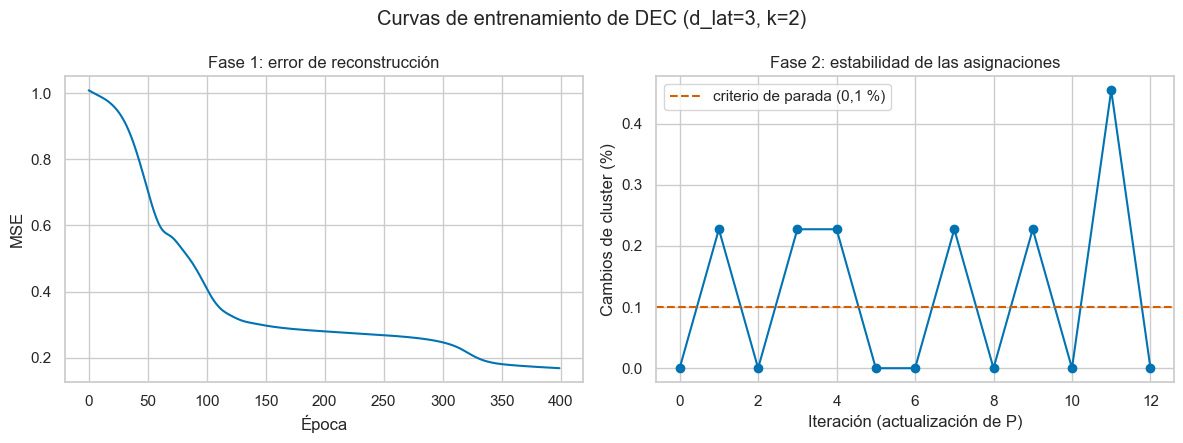

Tamaños de los clusters: [261 179]


In [25]:
etiquetas_dec, z_dec, historia_dec = entrenar_dec(X_esc, n_clusters=2, d_latente=3)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
ejes[0].plot(historia_dec["mse"], color=PALETA[0])
ejes[0].set_title("Fase 1: error de reconstrucción")
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("MSE")
ejes[1].plot(np.asarray(historia_dec["cambio"]) * 100, marker="o", color=PALETA[0])
ejes[1].axhline(0.1, color=PALETA[3], linestyle="--",
                label="criterio de parada (0,1 %)")
ejes[1].set_title("Fase 2: estabilidad de las asignaciones")
ejes[1].set_xlabel("Iteración (actualización de P)")
ejes[1].set_ylabel("Cambios de cluster (%)")
ejes[1].legend()
fig.suptitle("Curvas de entrenamiento de DEC (d_lat=3, k=2)")
fig.tight_layout()
guardar_figura(fig, "dec_entrenamiento")
plt.show()

etiquetas_finales["DEC (d_lat=3, k=2)"] = etiquetas_dec
print("Tamaños de los clusters:", np.bincount(etiquetas_dec))

**Interpretación.** La curva de reconstrucción del pre-entrenamiento converge de forma estable y la fase de refinamiento alcanza el criterio de parada en pocas iteraciones: desde el inicio del refinamiento solo entre 0 y 2 observaciones por iteración (≤ 0,5 %) cambian de cluster, hasta estabilizarse por completo — señal de que la partición heredada de la inicialización es esencialmente estable y el refinamiento se limita a afinar las fronteras. DEC produce así una partición binaria balanceada, coherente con la del baseline pero obtenida en un espacio latente aprendido de forma no lineal. El análisis comparativo formal de los cuatro métodos — incluida la contrastación con la pseudo-etiqueta de canal — se desarrolla en la sección 9.

## 9. Evaluación y comparación de métodos

Se comparan las particiones definitivas de los cuatro métodos mediante dos familias de métricas:

**Métricas internas** — evalúan la geometría de la partición sin información externa: **silhouette** (cohesión frente a separación, en [−1, 1], mayor es mejor), **Davies-Bouldin** (cociente promedio entre dispersión intra-cluster y separación entre clusters; menor es mejor) y **Calinski-Harabasz** (varianza entre clusters sobre varianza intra; mayor es mejor).

**Métricas externas** — miden la concordancia con la pseudo-etiqueta `Channel`: **ARI** (índice de Rand ajustado por azar; 0 equivale a una partición aleatoria) y **NMI** (información mutua normalizada). Corresponde subrayar la interpretación correcta de esta comparación: el canal **no es la verdad de terreno** de los segmentos — es una variable administrativa conocida —, de modo que un ARI alto indica que el método recupera estructura real verificable, pero un desacuerdo parcial no es necesariamente un error: puede reflejar estructura comercial genuina que trasciende al canal.

Dos precauciones para la lectura conjunta: (i) las métricas internas basadas en distancias euclídeas favorecen clusters compactos y esféricos, lo que penaliza estructuralmente a las componentes elipsoidales del GMM; y (ii) particiones con distinto k no son directamente comparables por una única métrica — la tabla debe leerse como un panel, no como un ranking.

In [26]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

filas = []
for nombre, etiq in etiquetas_finales.items():
    filas.append({
        "método": nombre,
        "silhouette ↑": silhouette_score(X_esc, etiq),
        "Davies-Bouldin ↓": davies_bouldin_score(X_esc, etiq),
        "Calinski-Harabasz ↑": calinski_harabasz_score(X_esc, etiq),
        "ARI (canal) ↑": adjusted_rand_score(df["Channel"], etiq),
        "NMI (canal) ↑": normalized_mutual_info_score(df["Channel"], etiq),
        "tamaños": np.bincount(etiq).tolist(),
    })

tabla_comparativa = pd.DataFrame(filas).set_index("método").round(3)
tabla_comparativa

,silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI (canal) ↑,NMI (canal) ↑,tamaños
método,,,,,,
"K-Means (k=2, referencia)",0.290,1.352,189.050,0.514,0.445,"[252, 188]"
"Agglomerative (Ward, k=3)",0.255,1.539,116.799,0.549,0.409,"[262, 53, 125]"
"GMM (full, k=3)",0.239,2.497,92.533,0.431,0.379,"[66, 224, 150]"
"DEC (d_lat=3, k=2)",0.285,1.369,181.799,0.546,0.457,"[261, 179]"


**Interpretación.** Cuatro lecturas se desprenden de la tabla:

1. **Toda la evidencia externa es positiva y sustancial** (ARI entre 0,43 y 0,55, muy por encima del 0 esperable por azar): los cuatro métodos recuperan, sin haberla visto, una estructura alineada con el canal de venta — se confirma la hipótesis formulada en 3.8.
2. **Las particiones binarias (K-Means y DEC) dominan las métricas internas**, como es esperable: a menor k, fronteras más nítidas. DEC replica casi exactamente la geometría del baseline (silhouette 0,285 frente a 0,290) pero alcanza la **mejor NMI (0,457)**; en un dataset tabular de solo 6 variables, el margen para que la representación no lineal aporte separación adicional es limitado — un resultado honesto que se retoma en la discusión.
3. **Agglomerative (Ward, k=3) logra el mejor ARI (0,549)** pese a usar tres grupos: su tercer cluster no rompe la correspondencia con el canal, sino que aísla un segmento genuinamente mixto, como muestra la tabla de contingencia siguiente.
4. **GMM presenta las peores métricas internas** (Davies-Bouldin 2,497), consecuencia directa de la precaución (i): sus componentes elipsoidales y solapadas son penalizadas por métricas que presuponen compacidad esférica. Su justificación es probabilística (BIC, sección 7), no geométrica — ilustración clara de que la elección de un método no puede delegarse en una única métrica.

Para entender *qué* estructura recupera cada método, la celda siguiente cruza las particiones con la pseudo-etiqueta (tablas de contingencia, en valores absolutos y porcentajes por fila).

In [27]:
for nombre in ["Agglomerative (Ward, k=3)", "GMM (full, k=3)", "DEC (d_lat=3, k=2)"]:
    etiq = pd.Series(etiquetas_finales[nombre], name="cluster")
    absolutos = pd.crosstab(etiq, df["Canal"])
    porcentajes = (absolutos.div(absolutos.sum(axis=1), axis=0) * 100).round(1)
    print(f"--- {nombre} ---")
    print(pd.concat([absolutos, porcentajes.add_suffix(" (%)")], axis=1), "\n")

--- Agglomerative (Ward, k=3) ---
Canal    Horeca  Retail  Horeca (%)  Retail (%)
cluster                                        
0           251      11        95.8         4.2
1            27      26        50.9        49.1
2            20     105        16.0        84.0 

--- GMM (full, k=3) ---
Canal    Horeca  Retail  Horeca (%)  Retail (%)
cluster                                        
0            56      10        84.8        15.2
1           214      10        95.5         4.5
2            28     122        18.7        81.3 

--- DEC (d_lat=3, k=2) ---
Canal    Horeca  Retail  Horeca (%)  Retail (%)
cluster                                        
0           251      10        96.2         3.8
1            47     132        26.3        73.7 



**Interpretación.** Los tres métodos coinciden en el eje principal pero difieren en el matiz que agregan:

- **Agglomerative (Ward, k=3)** produce un cluster Horeca casi puro (95,8 % de 262 clientes), un cluster de mayoría Retail (84,0 % de 125) y un **tercer segmento genuinamente mixto** (53 clientes, 50,9 % / 49,1 %): un grupo de comportamiento de compra que el canal no explica.
- **GMM (full, k=3)** particiona de otro modo: aísla el núcleo Retail (81,3 % de 150) y **subdivide el universo Horeca** en una componente grande casi pura (95,5 % de 224) y una componente menor (66 clientes) de perfil atípico.
- **DEC (k=2)** reproduce la dicotomía con alta pureza: 96,2 % de Horeca en un grupo y 73,7 % de Retail en el otro.

La estructura dominante de los datos es, en definitiva, la separación Horeca/Retail; el valor diferencial de los métodos con k = 3 está en el matiz que revelan (un segmento mixto en Ward; una subdivisión interna de Horeca en GMM). La caracterización comercial de estos grupos se desarrolla en la sección 10.

## 10. Visualización con t-SNE

Para visualizar la estructura de grupos en dos dimensiones se emplea **t-SNE** (*t-distributed Stochastic Neighbor Embedding*; van der Maaten y Hinton, 2008), técnica no lineal que satisface el requisito de utilizar un método distinto de PCA. t-SNE construye distribuciones de similitud entre pares de observaciones en el espacio original y en el plano, y minimiza la divergencia KL entre ambas, privilegiando la preservación de las **vecindades locales**.

Sus limitaciones condicionan la lectura de las figuras y conviene explicitarlas: (i) las **distancias globales** entre grupos y los **tamaños aparentes** de los clusters no son interpretables — solo lo es la estructura de vecindad; (ii) el resultado depende de la semilla (fijada aquí para reproducibilidad); y (iii) el hiperparámetro **perplexity** — interpretable como el número efectivo de vecinos que cada punto considera — modifica sustancialmente la representación. Por ello, antes de fijar una proyección se explora perplexity ∈ {5, 30, 50}, coloreando por canal para evaluar qué valor revela mejor la estructura ya validada en la sección 9.

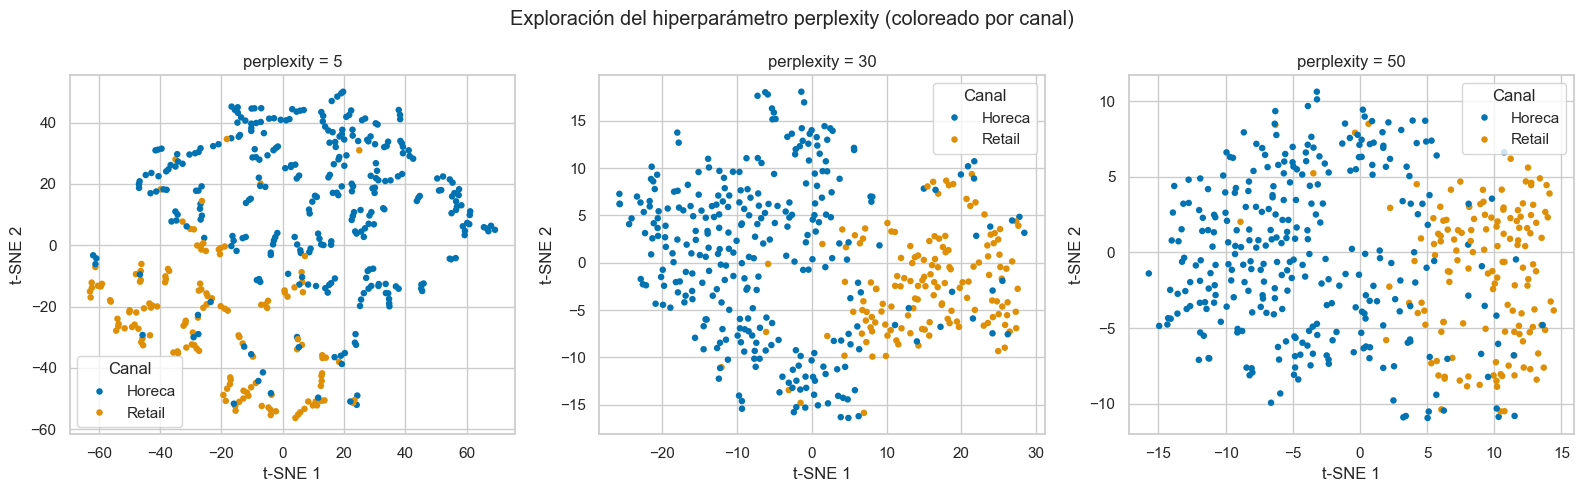

In [28]:
from sklearn.manifold import TSNE

perplejidades = [5, 30, 50]
proyecciones = {}

fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
for eje, per in zip(ejes, perplejidades):
    tsne = TSNE(n_components=2, perplexity=per, init="pca",
                learning_rate="auto", random_state=RANDOM_STATE)
    proyecciones[per] = tsne.fit_transform(X_esc)
    sns.scatterplot(x=proyecciones[per][:, 0], y=proyecciones[per][:, 1],
                    hue=df["Canal"], hue_order=["Horeca", "Retail"],
                    palette=COLOR_CANAL, s=22, edgecolor="none", ax=eje)
    eje.set_title(f"perplexity = {per}")
    eje.set_xlabel("t-SNE 1")
    eje.set_ylabel("t-SNE 2")
fig.suptitle("Exploración del hiperparámetro perplexity (coloreado por canal)")
fig.tight_layout()
guardar_figura(fig, "tsne_perplexity")
plt.show()

**Interpretación y elección.** Con perplexity = 5 la proyección se fragmenta en múltiples agrupamientos locales pequeños: el número efectivo de vecinos es demasiado bajo y la representación sobreajusta el ruido local. Con 30 y 50 la estructura global se estabiliza en dos regiones dominantes claramente asociadas al canal, con una zona de transición entre ambas. Se adopta **perplexity = 30** — el valor recomendado por los autores para muestras de este orden (~7 % de las 440 observaciones) — ya que 50 no aporta estructura adicional y tiende a sobre-compactar.

Sobre la proyección elegida, la celda siguiente compara visualmente las particiones de los cuatro métodos junto con las dos variables categóricas reservadas.

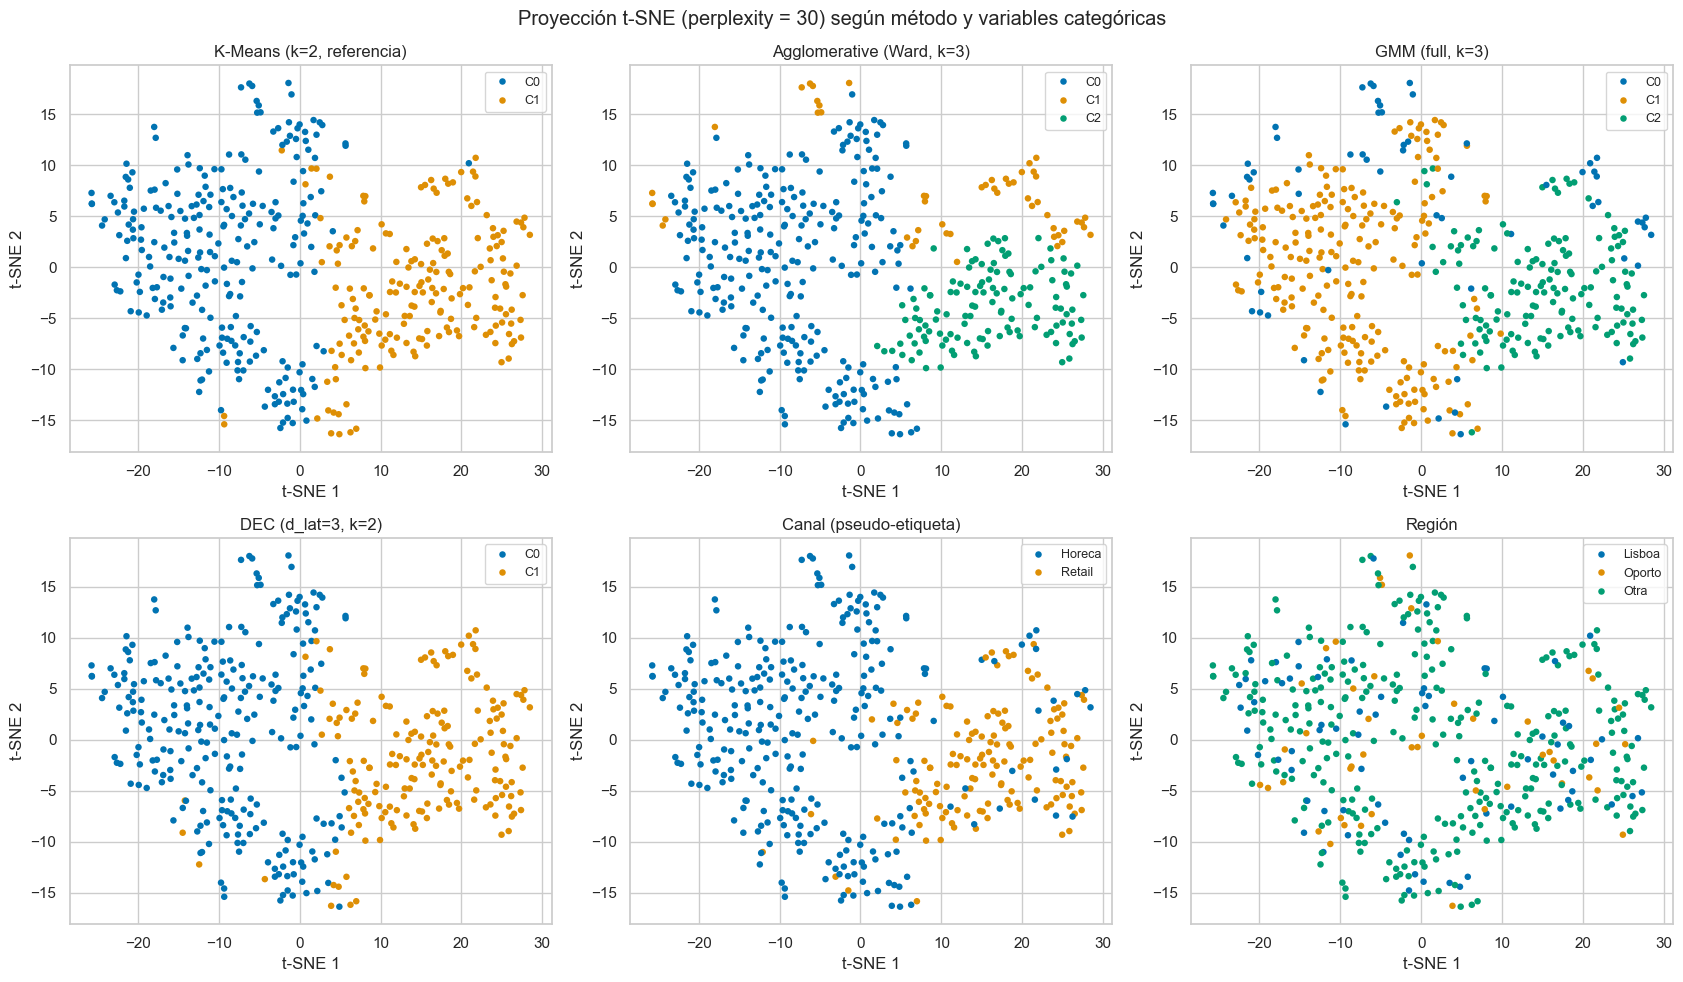

In [29]:
proy = proyecciones[30]

paneles = [(nombre, np.char.add("C", etiq.astype(str)), None)
           for nombre, etiq in etiquetas_finales.items()]
paneles += [("Canal (pseudo-etiqueta)", df["Canal"].to_numpy(), COLOR_CANAL),
            ("Región", df["Región"].to_numpy(), None)]

fig, ejes = plt.subplots(2, 3, figsize=(17, 10))
for eje, (titulo, etiq, paleta) in zip(ejes.ravel(), paneles):
    orden = sorted(pd.unique(etiq))
    sns.scatterplot(x=proy[:, 0], y=proy[:, 1], hue=etiq, hue_order=orden,
                    palette=paleta if paleta else "colorblind",
                    s=22, edgecolor="none", ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel("t-SNE 1")
    eje.set_ylabel("t-SNE 2")
    eje.legend(loc="best", fontsize=9)
fig.suptitle("Proyección t-SNE (perplexity = 30) según método y variables categóricas")
fig.tight_layout()
guardar_figura(fig, "tsne_metodos")
plt.show()

**Interpretación.** La proyección confirma visualmente las conclusiones cuantitativas de la sección 9:

- La nube presenta **dos regiones dominantes** que coinciden con el canal (panel *Canal*), unidas por una **zona de transición** sin frontera nítida — coherente con los valores moderados de silhouette obtenidos por todos los métodos: los grupos existen, pero no están completamente separados.
- K-Means, DEC y la dicotomía del canal delimitan esencialmente la misma frontera; las diferencias entre métodos se concentran en la zona de transición.
- El tercer cluster de **Ward** se concentra en el margen superior de la proyección, a caballo entre ambas regiones — es el segmento mixto identificado en 9, cuyos clientes son vecinos tanto de Horeca como de Retail —, mientras que la componente pequeña del **GMM** se distribuye por la periferia superior e izquierda de la región Horeca, consistente con su carácter de subdivisión interna de ese canal.
- El panel *Región* no muestra ningún patrón espacial: la estructura de los datos es conductual (canasta de compra), **no geográfica**, en línea con la composición regional uniforme de los clusters.

### 10.1 Perfilado de los segmentos

Para traducir la segmentación a términos de negocio se caracteriza cada cluster de la partición de **Ward (k = 3)** — la de mejor ARI y mayor riqueza interpretativa — mediante la **mediana** del gasto anual por categoría **en la escala original** (u.m.): la mediana es robusta frente a los valores extremos conservados y la escala original es la interpretable comercialmente. En el mapa de calor, el color codifica el perfil relativo (cada variable normalizada por su máximo entre segmentos) y las anotaciones muestran las medianas en u.m.

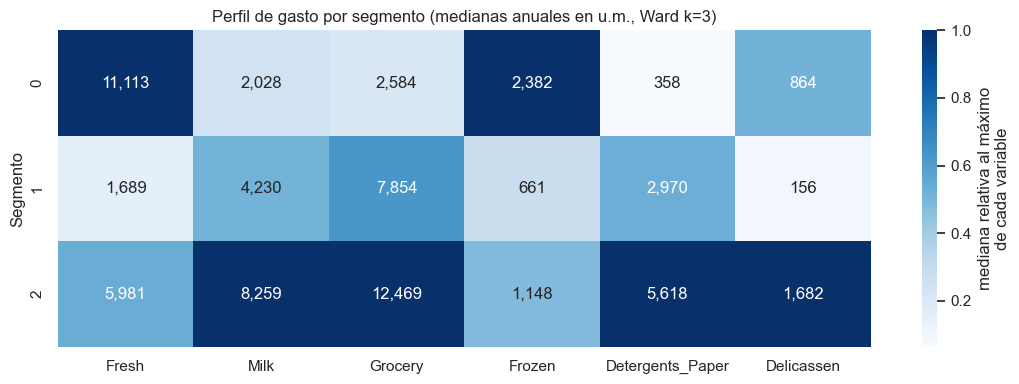

,clientes,"gasto total anual (mediana, u.m.)",% Horeca,% Retail
segmento,,,,
0,262,22072.0,95.8,4.2
1,53,23523.0,50.9,49.1
2,125,38694.0,16.0,84.0


In [30]:
perfil = df.copy()
perfil["segmento"] = etiquetas_finales["Agglomerative (Ward, k=3)"]

medianas = perfil.groupby("segmento")[VARS_GASTO].median()
relativo = medianas / medianas.max()

fig, eje = plt.subplots(figsize=(11, 4))
sns.heatmap(relativo, annot=medianas, fmt=",.0f", cmap="Blues",
            cbar_kws={"label": "mediana relativa al máximo\nde cada variable"}, ax=eje)
eje.set_title("Perfil de gasto por segmento (medianas anuales en u.m., Ward k=3)")
eje.set_ylabel("Segmento")
fig.tight_layout()
guardar_figura(fig, "perfil_segmentos")
plt.show()

perfil["gasto_total"] = perfil[VARS_GASTO].sum(axis=1)
composicion = pd.crosstab(perfil["segmento"], perfil["Canal"], normalize="index") * 100
resumen_segmentos = pd.DataFrame({
    "clientes": perfil["segmento"].value_counts().sort_index(),
    "gasto total anual (mediana, u.m.)": perfil.groupby("segmento")["gasto_total"].median(),
    "% Horeca": composicion["Horeca"].round(1),
    "% Retail": composicion["Retail"].round(1),
})
resumen_segmentos

**Caracterización e insights de negocio.** Los tres segmentos admiten una lectura comercial directa:

- **Segmento 0 — Frescos (perfil Horeca).** 262 clientes (95,8 % Horeca). Gasto concentrado en `Fresh` (mediana 11 113 u.m.) y `Frozen`, con consumo casi nulo de detergentes (358 u.m.). Perfil de hostelería intensiva en insumos perecederos: prioridad para la logística de cadena de frío y frecuencia de reparto.
- **Segmento 1 — Reposición de bajo volumen (mixto).** 53 clientes repartidos por igual entre canales (50,9 % / 49,1 %). Canasta de reposición a pequeña escala (`Grocery` 7 854, `Detergents_Paper` 2 970 u.m.) con frescos y delicatessen marginales (1 689 y 156 u.m.). Es el grupo que el canal no explica — un hallazgo genuino del enfoque no supervisado — y, por su perfil incompleto de canasta, el candidato natural para acciones de desarrollo de cuenta y venta cruzada.
- **Segmento 2 — Reposición de gran volumen (perfil Retail).** 125 clientes (84,0 % Retail). Máximos en toda la canasta minorista (`Grocery` 12 469, `Milk` 8 259, `Detergents_Paper` 5 618, `Delicassen` 1 682 u.m.) y el mayor gasto total (mediana 38 694 u.m., frente a ~22 000–23 500 de los otros segmentos): el núcleo de facturación del distribuidor, prioritario para políticas de retención.

La composición regional de los tres segmentos es prácticamente idéntica (70–75 % de clientes de regiones \"Otra\" en todos), lo que refuerza la conclusión de la proyección t-SNE: la segmentación útil de esta cartera es **conductual y no geográfica**.

## 11. Discusión y conclusiones

### 11.1 Discusión

**Sobre la estructura de los datos.** Los cuatro métodos, con supuestos y mecanismos muy distintos, convergen en el mismo hallazgo central: la cartera de clientes se organiza en torno a la dicotomía Horeca/Retail, recuperada sin supervisión con ARI entre 0,43 y 0,55. Los valores moderados de silhouette (0,24–0,29) y la zona de transición visible en la proyección t-SNE indican, no obstante, que los grupos son reales pero **no están nítidamente separados**: una fracción de los clientes presenta canastas híbridas, y cualquier segmentación operativa debería tratar esas fronteras como graduales.

**Sobre el aporte diferencial de cada método.** Agglomerative con enlace de Ward aportó la partición más informativa (mejor ARI y un tercer segmento genuinamente mixto que el canal no explica); el GMM aportó la lectura probabilística — la identificación del 8,2 % de clientes fronterizos y la selección de modelo por BIC, coherente con la estructura de covarianzas detectada en el EDA —; DEC alcanzó la mejor NMI (0,457) y validó el pipeline de deep clustering. Corresponde una valoración honesta de este último: su partición es geométricamente casi idéntica a la del baseline K-Means (silhouette 0,285 frente a 0,290). En un dataset tabular de solo 6 variables — donde la relación no lineal dominante ya fue capturada por la transformación logarítmica del preprocesamiento — el margen para que una representación latente no lineal aporte separación adicional es reducido; el valor de DEC en este trabajo es metodológico, y cabría esperar ventajas mayores en datos de alta dimensionalidad.

**Limitaciones.** (i) El tamaño muestral (440 observaciones) es reducido para métodos de deep clustering, cuyos resultados deben leerse como prueba de concepto; (ii) `Channel` es una pseudo-etiqueta administrativa, no la verdad de terreno de los segmentos, por lo que las métricas externas miden recuperación de estructura conocida y no calidad absoluta; (iii) las métricas internas empleadas presuponen clusters compactos y esféricos, lo que penaliza estructuralmente al GMM; (iv) la influencia de los valores extremos fue mitigada por la transformación logarítmica pero no eliminada — los clientes de gasto casi nulo permanecen como cola inferior; y (v) t-SNE se utilizó exclusivamente para visualización: agrupar sobre la proyección habría introducido las distorsiones globales propias del método.

### 11.2 Conclusiones

1. **Calidad y preparación de los datos.** El dataset está completo y sin duplicados; la asimetría severa del gasto (coeficientes de 2,6 a 11,2) exigió una transformación logarítmica que, junto con la estandarización, redujo las filas con valores atípicos del 24,5 % al 9,5 % sin descartar observaciones — decisión preferible a la eliminación, al tratarse de clientes reales de gran volumen.
2. **Estructura recuperada.** Existe estructura de grupos real y verificable, alineada con el canal de venta y de naturaleza **conductual, no geográfica**: la región no ordena los datos ni en las composiciones de los clusters ni en la proyección t-SNE.
3. **Segmentación propuesta.** La partición de Agglomerative (Ward, k=3) ofrece la segmentación más accionable: *Frescos–Horeca* (262 clientes), *Reposición de bajo volumen–mixto* (53 clientes, hallazgo genuino del enfoque no supervisado y candidato natural a venta cruzada) y *Reposición de gran volumen–Retail* (125 clientes, mediana de gasto total de 38 694 u.m., núcleo de facturación del distribuidor).
4. **Lección metodológica.** Ninguna métrica aislada habría conducido a una buena decisión: la silhouette máxima correspondía a particiones degeneradas (sección 6), las métricas internas penalizan al GMM por su geometría elipsoidal (sección 9) y la selección de hiperparámetros exigió combinar criterios cuantitativos (BIC, silhouette, Davies-Bouldin) con inspección estructural (dendrograma, tamaños de clusters) y validación externa a posteriori.

### 11.3 Líneas de trabajo futuro

- **Métodos basados en densidad** (DBSCAN/HDBSCAN), que no fijan k a priori y tratan los valores atípicos de forma nativa, como contraste adicional.
- **Variantes de deep clustering** que preservan la reconstrucción durante el refinamiento (IDEC) o enfoques generativos (VaDE), potencialmente más estables en muestras pequeñas.
- **Agrupamiento por consenso** entre las particiones obtenidas, para derivar una segmentación única robusta.
- **Enriquecimiento del dataset** (series temporales de compra, márgenes, antigüedad del cliente) y validación de la segmentación contra indicadores comerciales (retención, venta cruzada, rentabilidad por segmento).

## 12. Referencias

- Cardoso, M. (2013). *Wholesale customers* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5030X
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- van der Maaten, L., & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9(86), 2579–2605.
- Wong, B. (2011). Points of view: Color blindness. *Nature Methods*, 8(6), 441.
- Xie, J., Girshick, R., & Farhadi, A. (2016). Unsupervised Deep Embedding for Clustering Analysis. *Proceedings of the 33rd International Conference on Machine Learning* (ICML).